In [2]:
# --------------------------------------------------
# Importing necessary libraries
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
import wfdb
import sys

# --------------------------------------------------
# Setting up paths
# --------------------------------------------------
ROOT      = Path.cwd().parent                          # ecg-ai-statistical-evaluation/
DATA      = ROOT / 'data'                              # ecg-ai-statistical-evaluation/data/

PTBXL_DB  = DATA / 'ptbxl_database.csv'               # patient demographics
SCP       = DATA / 'scp_statements.csv'                # SCP codes

# --------------------------------------------------
# Sanity checks
# --------------------------------------------------
assert ROOT.exists(),      f"Project root not found: {ROOT}"
assert PTBXL_DB.exists(),  f"Metadata CSV not found: {PTBXL_DB}"
assert SCP.exists(),       f"SCP statements not found: {SCP}"
#assert ECG_100HZ.exists(), f"records100 not found: {ECG_100HZ}"
print(f"All paths verified. Root: {ROOT.resolve()}")
# -------------------------------------------------
# Import modules
# -------------------------------------------------
sys.path.append(str(ROOT / 'modules'))

from eda_metadata  import (cohort_summary_stats, plot_cohort_summary_stats,
                            demographics_by_superclass,
                            plot_demographics_by_superclass, plot_cooccurrence)
from eda_signal    import (load_sample_per_class, load_quality_samples,
                            load_all_signals, load_split_signals, sample_signals,
                            compute_lead_stats, compute_lead_stats,
                            compute_mean_psd, plot_ecg, plot_quality_comparison, plot_lead_stats,
                            plot_psd, plot_preprocessing_comparison)
from preprocessing import bandpass_filter, normalize, preprocess

All paths verified. Root: C:\Users\delga\OneDrive\Documents\personal_projects\DeepAF Automated Atrial Fibrillation Detection\ecg-ai-statistical-evaluation


In [15]:
# Module-level constants
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

## 1️⃣ Load the Data

In [3]:
# --------------------------------------------------
# Loading Patient Information
# --------------------------------------------------
df = pd.read_csv(PTBXL_DB, sep=",", index_col='ecg_id')

# print basic info about the dataframe
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  object 
 8   recording_date                21799 non-null  object 
 9   report                        21799 non-null  object 
 10  scp_codes                     21799 non-null  object 
 11  heart_axis                    13331 non-null  object 
 12  infarction_stadium1           5612 non-null   object 
 13  infarc

In [4]:
df.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


# 2️⃣ Diagnostic Labels

The diagnostic Labels are in a format where more than 1 condition can be present based on the ECG and cardiologist interpretation. These classifications are the scp codes. The possible scp codes are `['NORM','MI','STTC','CD','HYP']`. These are the five major dignostic superclasses used to classify ECG signals. 
* NORM: Normal ECG
* MI (Myocardial Infarction): Indicates heart attacks. 
* STTC (ST/T Change): Indicates abnormalitioes in the ST segment or the T wave. 
* CD (Conduction Disturbance): Disturbances in the heart's electrical conduction system.
* HYP (Hypertrophy): Enlargement of the heart muscle. 

Source: [PubMed, Deep Learning Models for Arrhythmia Classification Based on ECG Signals Using PTB-X Dataset](https://pmc.ncbi.nlm.nih.gov/articles/PMC12346745/)

Need to encode these classifications which act as our ground truth through Multilabel Encoder.

In [5]:
# -- 2. Load SCP statements & filter to diagnostic only --
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Load SCP statements to get superclass mappings
agg_df = pd.read_csv('../data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# -- 3. Map SCP Codes -> Diagnostic superclass
def get_superclass(scp_dict):
    classes = []
    # Loop through the scp_dict for an ECG interpretation
    for key in scp_dict.keys():
        # Add present SCP codes under a new column called diagnostic_class and store it into classes 
        if key in agg_df.index:
            classes.append(agg_df.loc[key, 'diagnostic_class'])
    return list(set(classes))

df['superclass'] = df['scp_codes'].apply(get_superclass)
df = df[df['superclass'].map(len) > 0]  # drop records with no diagnostic label

print(df['superclass'].value_counts())

superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[HYP, STTC]             781
[MI, STTC]              599
[HYP]                   535
[STTC, CD]              471
[NORM, CD]              407
[MI, HYP, STTC]         361
[HYP, CD]               300
[MI, STTC, CD]          223
[HYP, STTC, CD]         211
[MI, HYP]               183
[MI, HYP, STTC, CD]     156
[MI, HYP, CD]           117
[NORM, STTC]             28
[NORM, STTC, CD]          5
[NORM, HYP, CD]           2
[NORM, HYP]               2
[MI, NORM, HYP, CD]       1
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import MultiLabelBinarizer
# -- 4. Apply Multilabel Binarizer --

# Encode the SCP codes where 1 indictaes condition is present and 0 indictes it is not
mlb = MultiLabelBinarizer(classes=['NORM','MI','STTC','CD','HYP'])
Y = mlb.fit_transform(df['superclass']) # The shape should be (N, 5)
print(Y.shape)

(21388, 5)


In [7]:
# ---------------------------------------------------
# Sanity Checks on the extracted superclasses
# ---------------------------------------------------

# Check how many ECGs have at least one diagnostic label
n_with_labels = (df["superclass"].apply(len) > 0).sum()
n_total = len(df)

print(f"ECGs with diagnostic labels: {n_with_labels}/{n_total}")
print(f"Percentage labeled: {100 * n_with_labels / n_total:.2f}%")

# Check for empty labels
empty_labels = df[df["superclass"].apply(len) == 0]
print("Number of ECGs with NO diagnostic superclass:", len(empty_labels))

ECGs with diagnostic labels: 21388/21388
Percentage labeled: 100.00%
Number of ECGs with NO diagnostic superclass: 0


In [8]:
# Count the occurrences of each superclass
all_classes = [cls for sublist in df["superclass"] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()

print("\nDiagnostic Superclass Counts:")
print(class_counts)


Diagnostic Superclass Counts:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


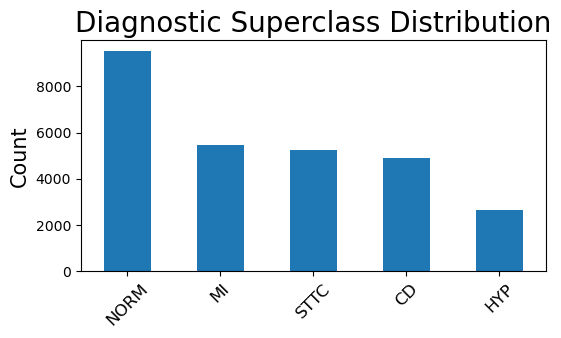

In [9]:
# -- Make a figure showing the Superclass Distributions --
plt.figure(figsize=(6, 3), facecolor='white')

# Define fontsizes
label = 15 
title = 20 
ticks = 12

# Plot class_counts
class_counts.plot(kind="bar")
plt.title("Diagnostic Superclass Distribution", fontsize=title)
plt.ylabel("Count", fontsize=label)
plt.xticks(rotation=45, fontsize=ticks)
plt.show()

### Define the splits 

In [10]:
# Define column split with default assigned as 'train'
df['split'] = 'train'

# folds 9 and 10 are meant to be validation and test folds 
df.loc[(df["strat_fold"] == 9), 'split'] = 'val' # assign validation to fold 9
df.loc[(df["strat_fold"] == 10), 'split'] = 'test' # assign test to fold 10

## Generate Table 1 Summary Statistics

Split: GLOBAL  (21,388 records)


,Characteristic,Value
0,Total ECG Recordings,"21,388"
1,Unique Patients,"18,617"
2,"Age (years), mean ± SD",59.8 ± 17.0
3,"Age (years), median (IQR)",62.0 (50.0–72.0)
4,Sex: Female,"10,277 (48.1%)"
5,Sex: Male,"11,111 (51.9%)"
6,Diagnosis: NORM,"9,514 (44.5%)"
7,Diagnosis: MI,"5,469 (25.6%)"
8,Diagnosis: STTC,"5,235 (24.5%)"
9,Diagnosis: CD,"4,898 (22.9%)"




Split: TRAIN  (17,084 records)


,Characteristic,Value
0,Total ECG Recordings,"17,084"
1,Unique Patients,"14,823"
2,"Age (years), mean ± SD",59.6 ± 16.9
3,"Age (years), median (IQR)",61.0 (50.0–72.0)
4,Sex: Female,"8,197 (48.0%)"
5,Sex: Male,"8,887 (52.0%)"
6,Diagnosis: NORM,"7,596 (44.5%)"
7,Diagnosis: MI,"4,379 (25.6%)"
8,Diagnosis: STTC,"4,186 (24.5%)"
9,Diagnosis: CD,"3,907 (22.9%)"




Split: VAL  (2,146 records)


,Characteristic,Value
0,Total ECG Recordings,"2,146"
1,Unique Patients,"1,917"
2,"Age (years), mean ± SD",60.2 ± 17.5
3,"Age (years), median (IQR)",62.0 (49.2–73.0)
4,Sex: Female,"1,032 (48.1%)"
5,Sex: Male,"1,114 (51.9%)"
6,Diagnosis: NORM,955 (44.5%)
7,Diagnosis: MI,540 (25.2%)
8,Diagnosis: STTC,528 (24.6%)
9,Diagnosis: CD,495 (23.1%)




Split: TEST  (2,158 records)


,Characteristic,Value
0,Total ECG Recordings,"2,158"
1,Unique Patients,"1,877"
2,"Age (years), mean ± SD",60.9 ± 17.6
3,"Age (years), median (IQR)",63.0 (50.0–74.0)
4,Sex: Female,"1,048 (48.6%)"
5,Sex: Male,"1,110 (51.4%)"
6,Diagnosis: NORM,963 (44.6%)
7,Diagnosis: MI,550 (25.5%)
8,Diagnosis: STTC,521 (24.1%)
9,Diagnosis: CD,496 (23.0%)


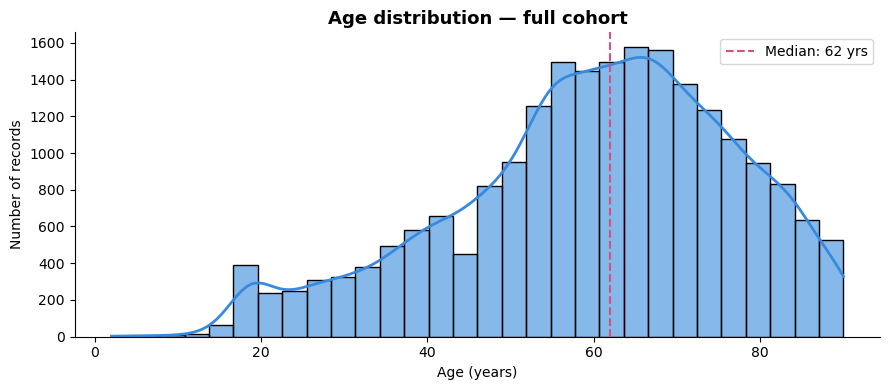

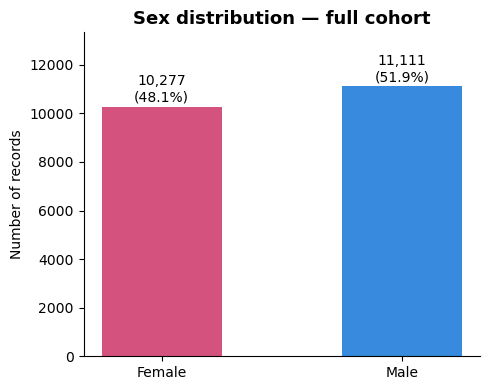

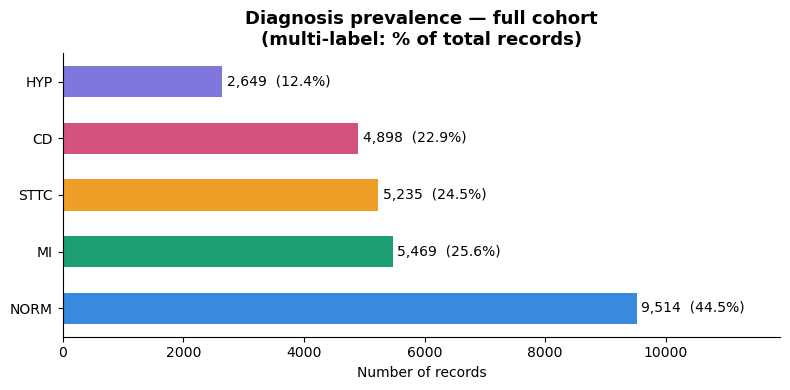

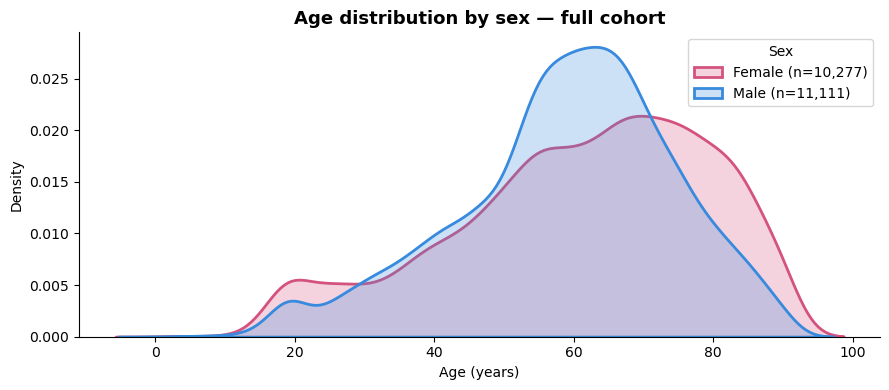

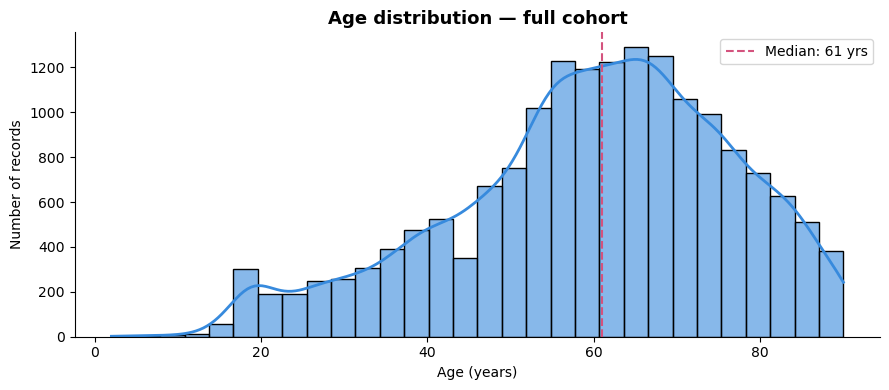

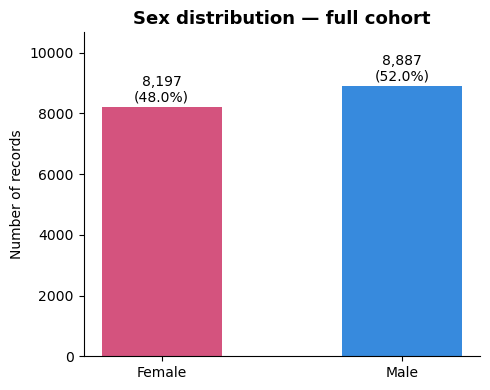

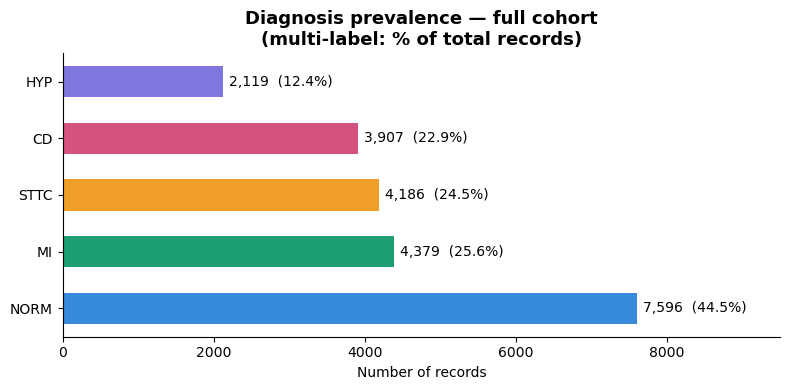

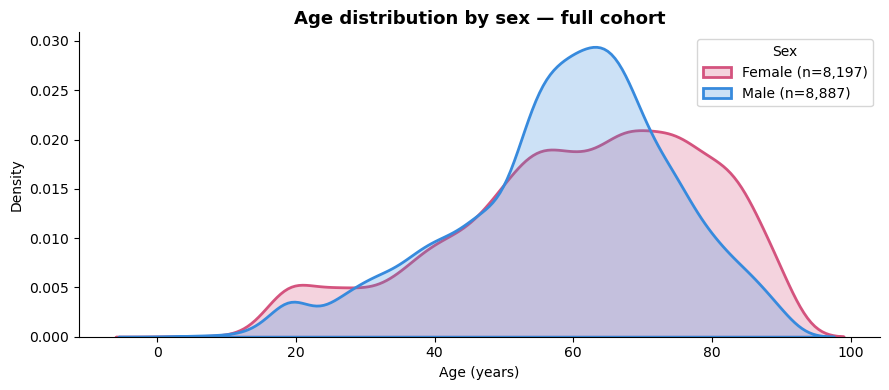

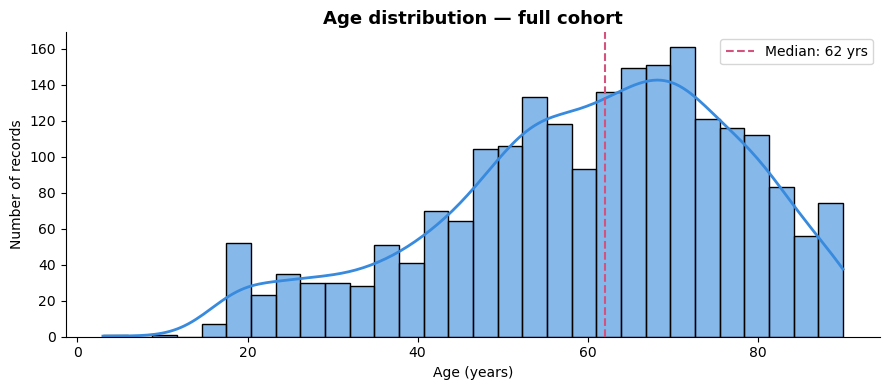

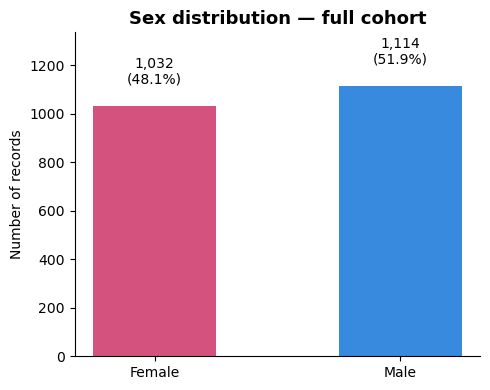

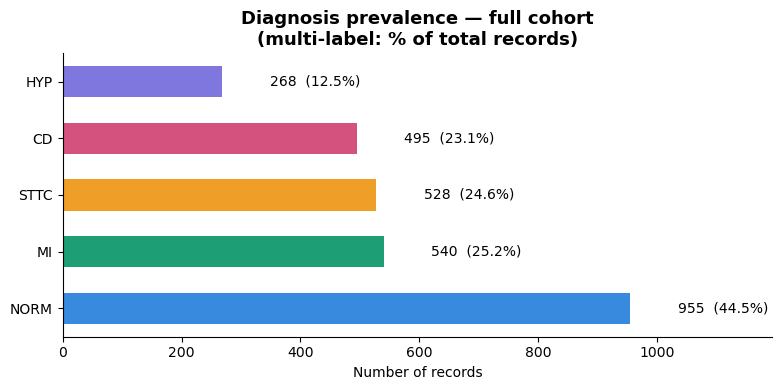

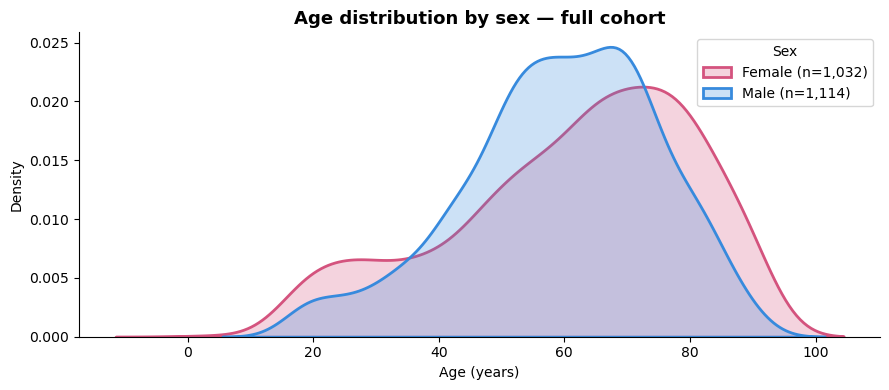

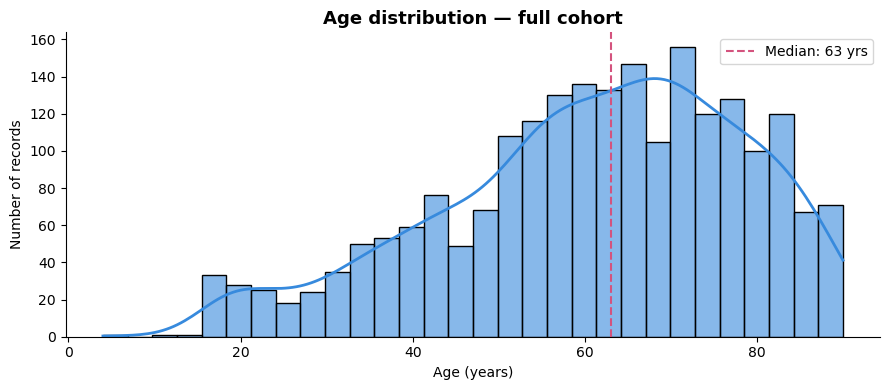

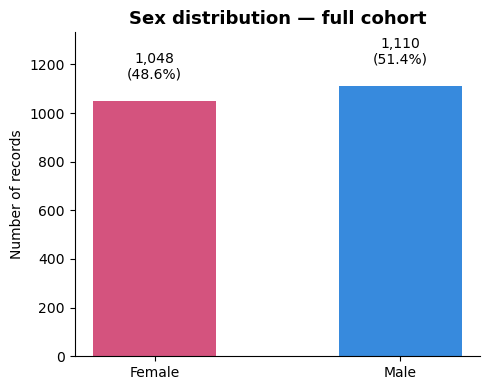

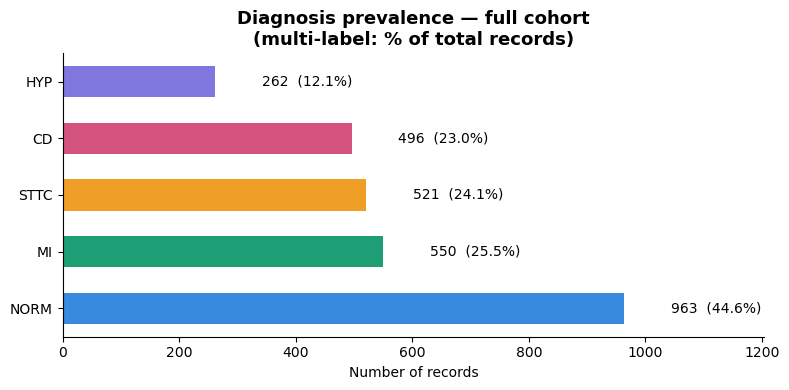

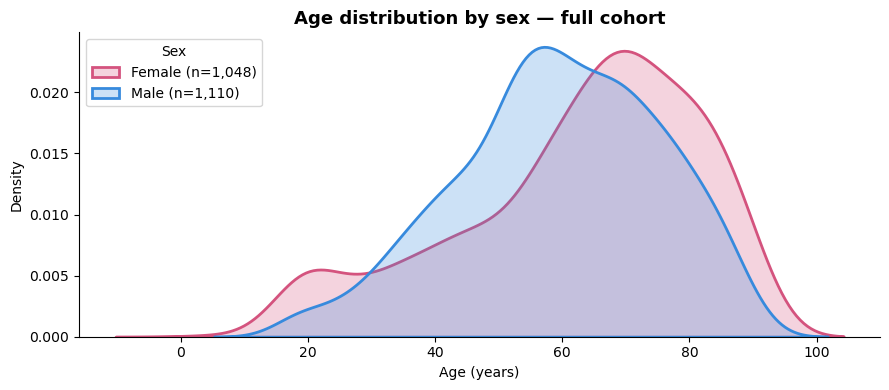

In [11]:
split_df = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

# ── Cohort summary stats + plots ──────────────────────────────────────────────
summary_tables = {}
cohort_plots   = {}

for key, df_split in split_df.items():
    print(f"{'='*60}")
    print(f"Split: {key.upper()}  ({len(df_split):,} records)")
    print(f"{'='*60}")

    summary_tables[key] = cohort_summary_stats(df_split)
    cohort_plots[key]   = plot_cohort_summary_stats(df_split)

    display(summary_tables[key])
    print("\n")

## Generate Table 2

Split: global (21,388 records)
           N (label count)    Mean ± SD      Median (IQR)         Female  \
superclass                                                                 
CD                   4,898  66.0 ± 15.4  68.0 (57.0–77.0)  1,899 (38.8%)   
HYP                  2,649  66.4 ± 14.2  68.0 (58.0–77.0)  1,129 (42.6%)   
MI                   5,469  66.8 ± 12.9  67.0 (58.0–76.0)  2,062 (37.7%)   
NORM                 9,514  52.2 ± 17.3  54.0 (40.0–65.0)  5,128 (53.9%)   
STTC                 5,235  66.9 ± 13.9  68.0 (58.0–77.0)  2,669 (51.0%)   

                     Male  female_pct  male_pct     n  
superclass                                             
CD          2,999 (61.2%)        38.8      61.2  4898  
HYP         1,520 (57.4%)        42.6      57.4  2649  
MI          3,407 (62.3%)        37.7      62.3  5469  
NORM        4,386 (46.1%)        53.9      46.1  9514  
STTC        2,566 (49.0%)        51.0      49.0  5235  
____________________________________________

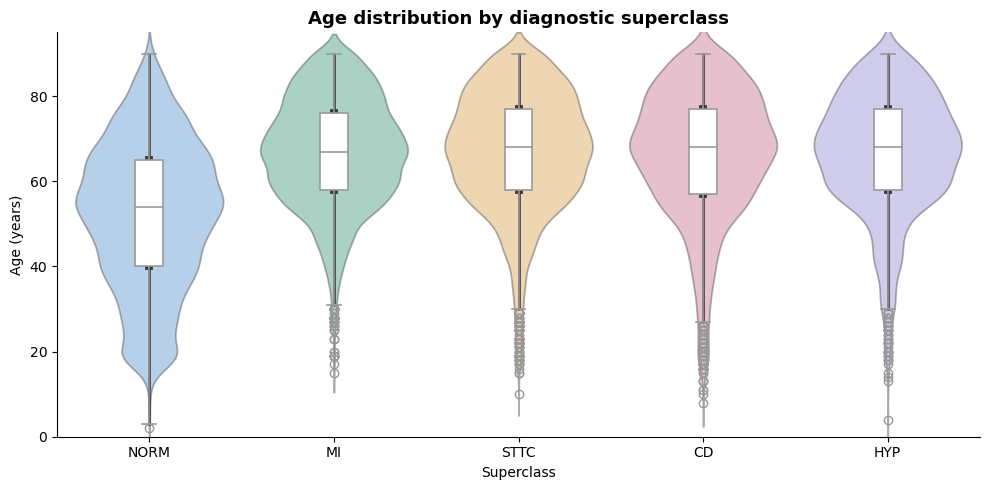

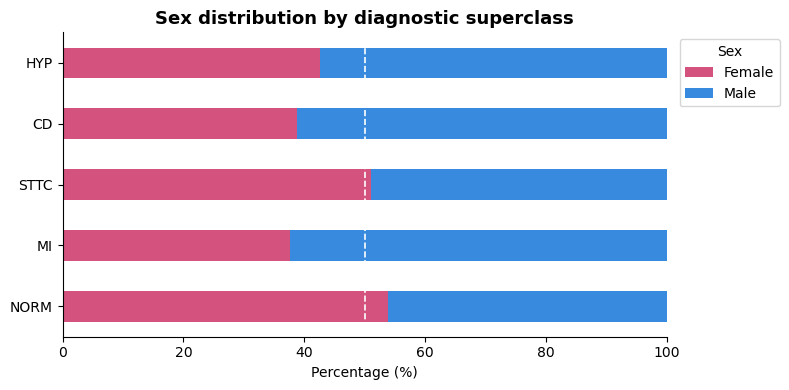

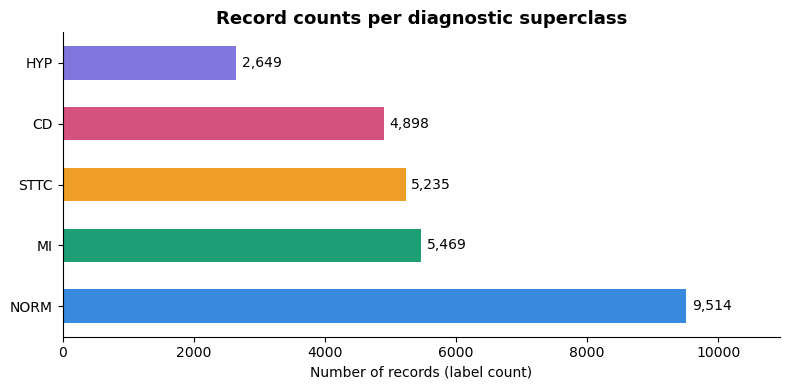

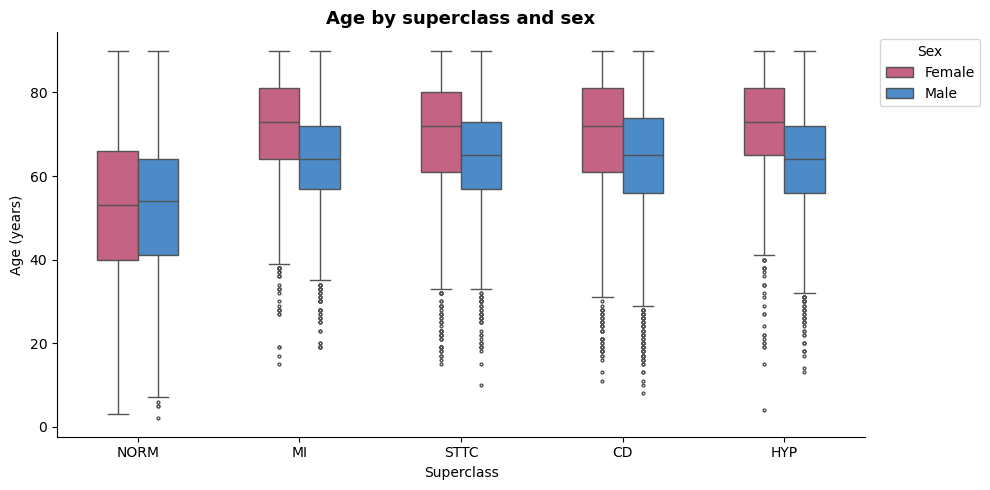

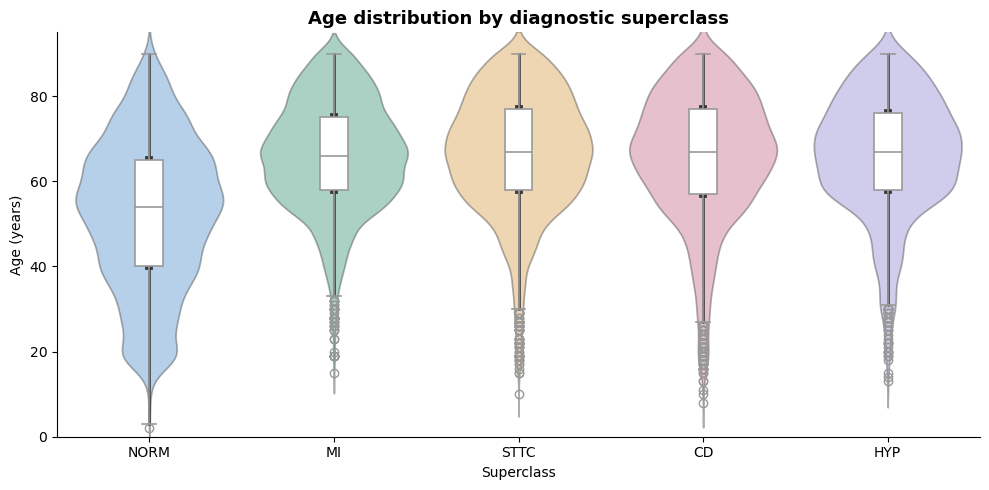

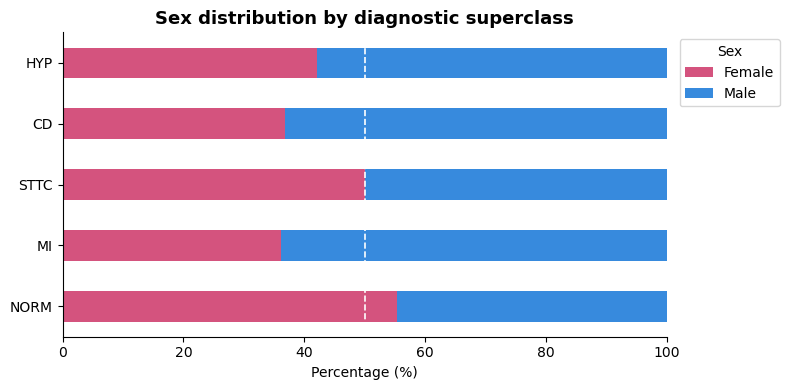

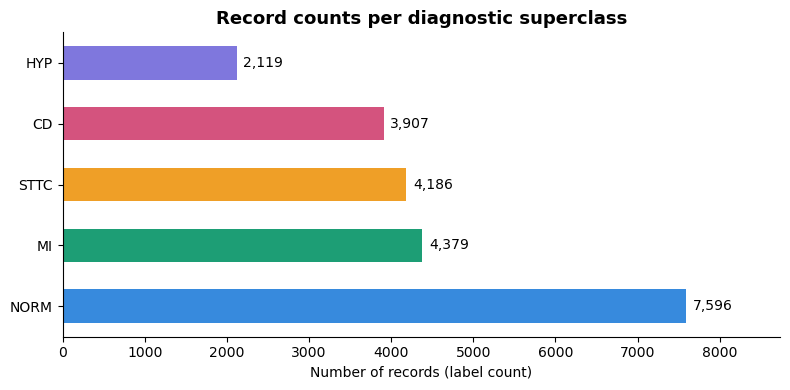

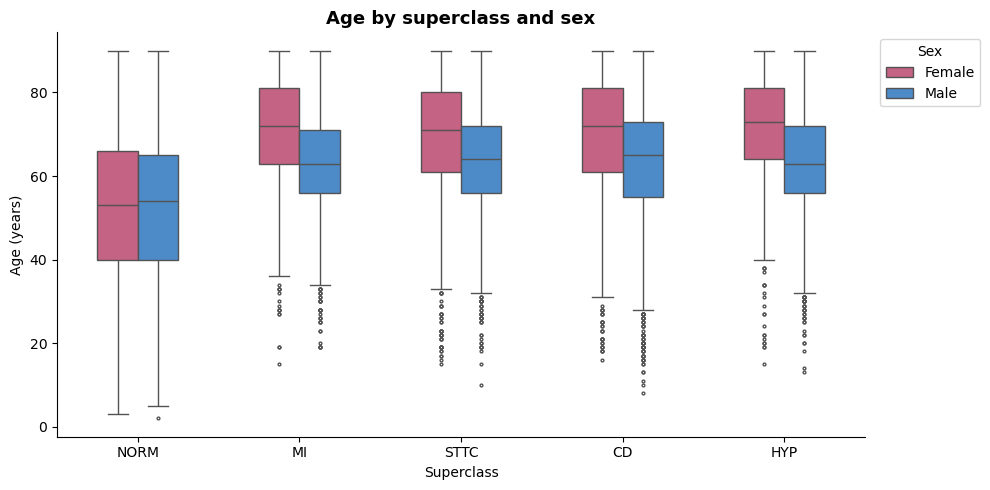

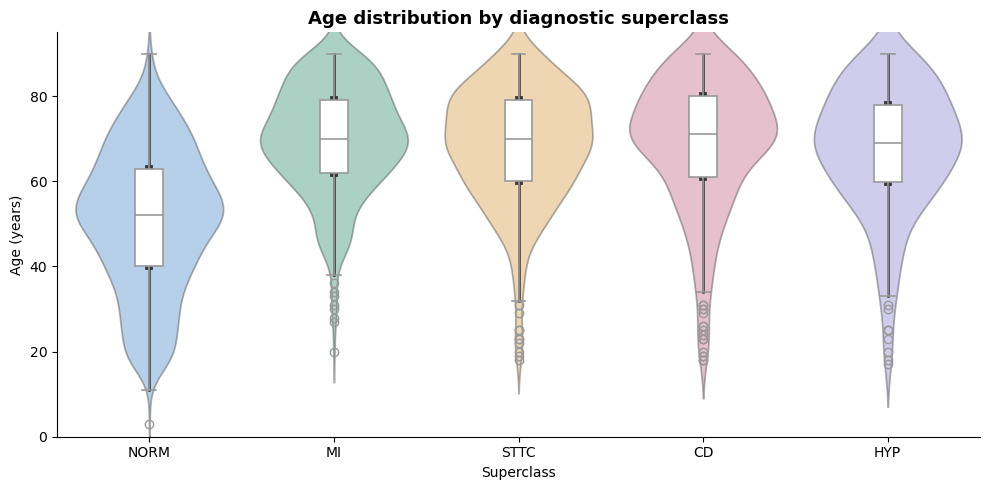

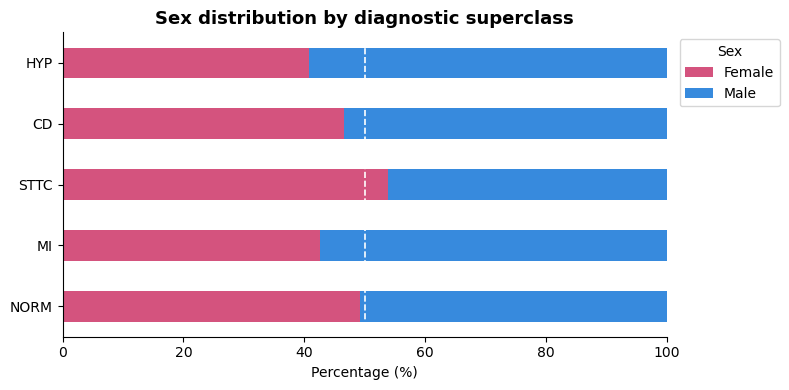

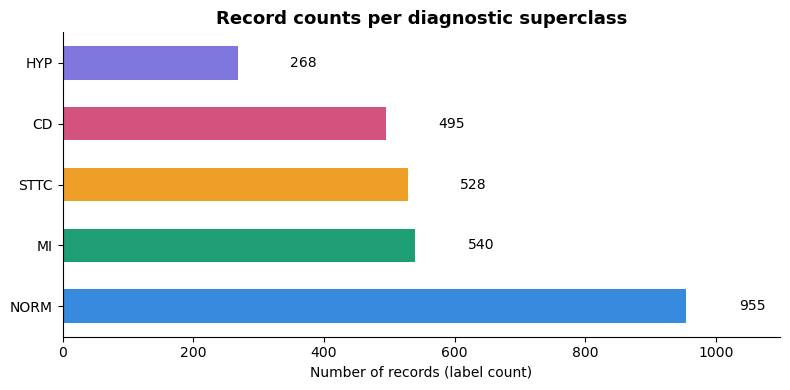

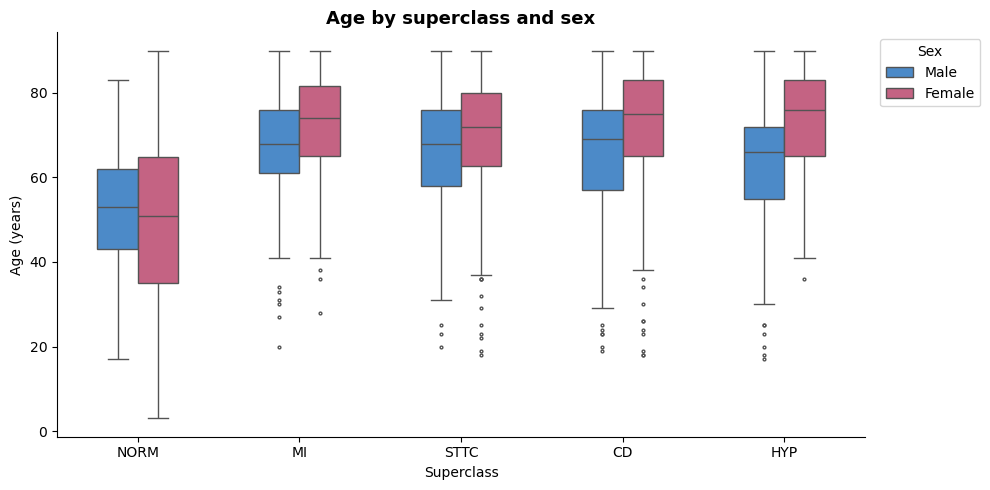

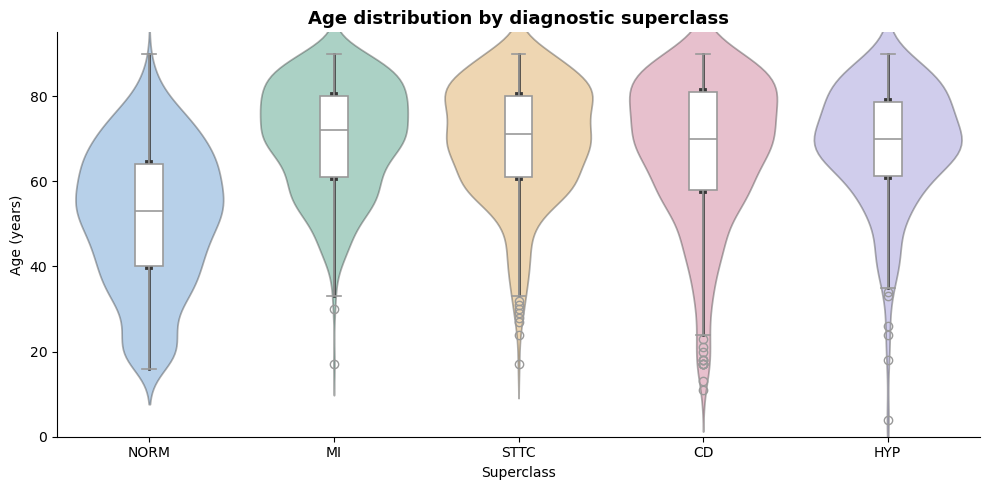

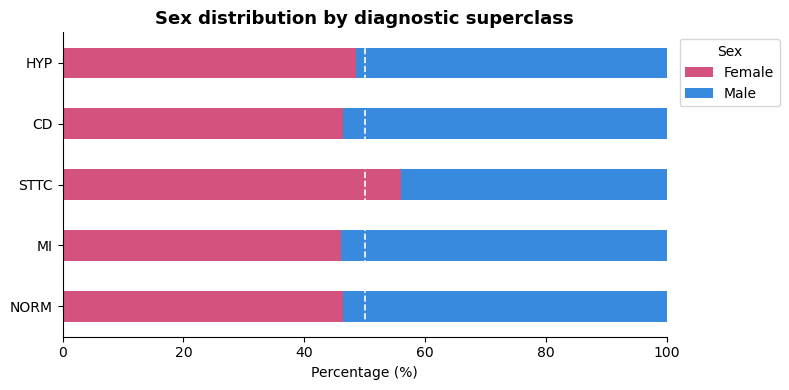

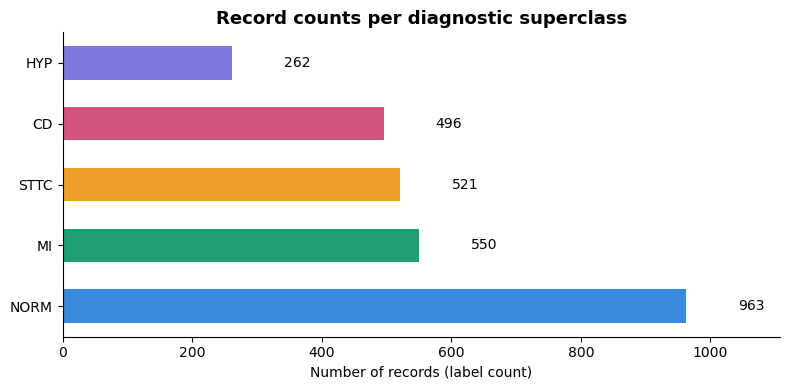

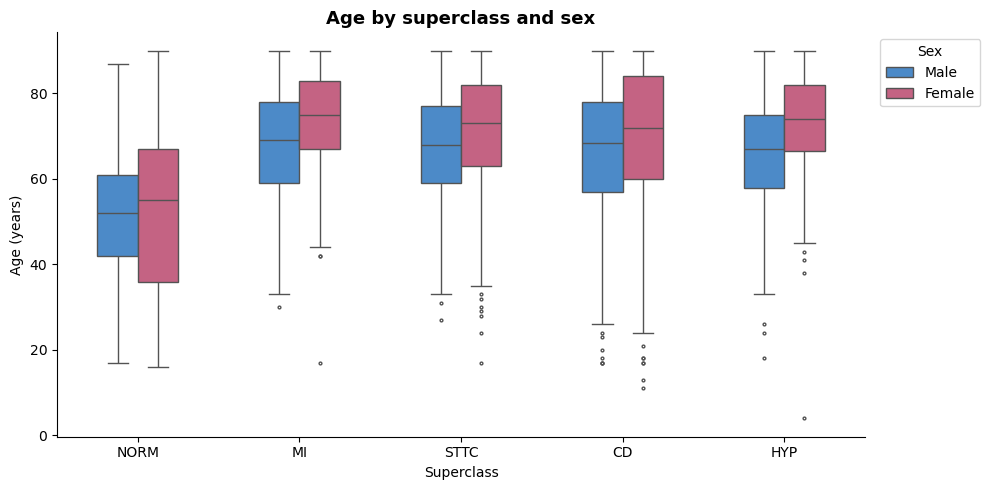

In [12]:
# View the superclass breakdown globally, train, test, val\
# Build split dictionary
split_df = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

# Loop through all splits and display stats
plots_splits = {}
for key, df_split in split_df.items():
    print(f"Split: {key} ({len(df_split):,} records)")
    
    stats, df_exploded = demographics_by_superclass(df_split)
    plots_splits[key]  = plot_demographics_by_superclass(stats, df_exploded)

    print(stats)
    print("_" * 100)
    print("\n")


### Compute Co-occurance 

In [13]:
from itertools import combinations

# Count how often each pair co-occurs 
pairs = []
for labels in df['superclass']:
    for a, b in combinations(sorted(labels), 2):
        pairs.append((a,b))

# Create dataframe storing co-occurance
cooc = pd.DataFrame(pairs, columns=["A", "B"]).value_counts().reset_index()

In [16]:
cooc

,A,B,count
0,CD,MI,1794
1,HYP,STTC,1509
2,MI,STTC,1339
3,CD,STTC,1066
4,HYP,MI,818
5,CD,HYP,787
6,CD,NORM,415
7,NORM,STTC,33
8,HYP,NORM,5
9,MI,NORM,1


In [17]:
# Pivot to square matrix
cooc_matrix = cooc.pivot(index='A', columns='B', values='count').fillna(0)

# Make it symmetric — currently only has (A,B) not (B,A) since combinations() is ordered
cooc_matrix = cooc_matrix.reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)
cooc_matrix = cooc_matrix + cooc_matrix.T  # mirror across diagonal

# Add diagonal — how many records contain each class at all
all_classes  = [cls for sublist in df['superclass'] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()
for cls in CLASS_ORDER:
    cooc_matrix.loc[cls, cls] = class_counts.get(cls, 0)

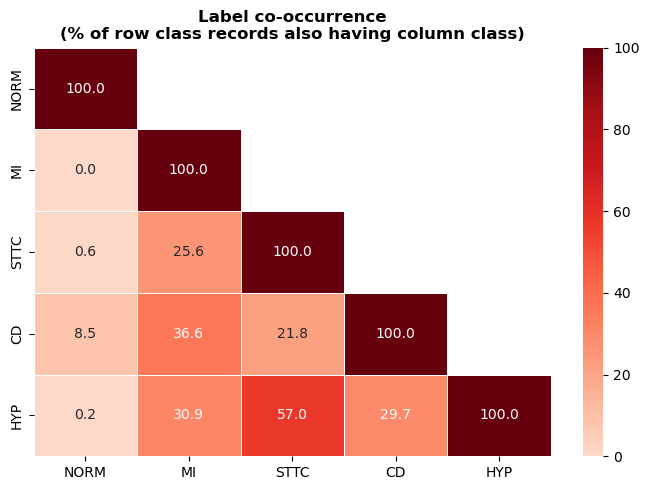

In [18]:
fig = plot_cooccurrence(cooc_matrix)

## Signal EDA

In addition to demographics of the study cohort there is also EDA on the ECG Signal. We will explore Power Spectral Density and the waveforms.

All Signal EDA will use 100 Hz 

In [19]:
samples = load_sample_per_class(df, DATA, fs=100)

# Sanity Check
for cls, sig in samples.items():
    print(f"{cls}: shape={sig.shape}, min={sig.min():.3f}, max={sig.max():.3f}")

NORM: shape=(1000, 12), min=-1.377, max=0.706
MI: shape=(1000, 12), min=-1.210, max=0.901
STTC: shape=(1000, 12), min=-1.805, max=0.779
CD: shape=(1000, 12), min=-2.933, max=1.879
HYP: shape=(1000, 12), min=-2.137, max=3.652


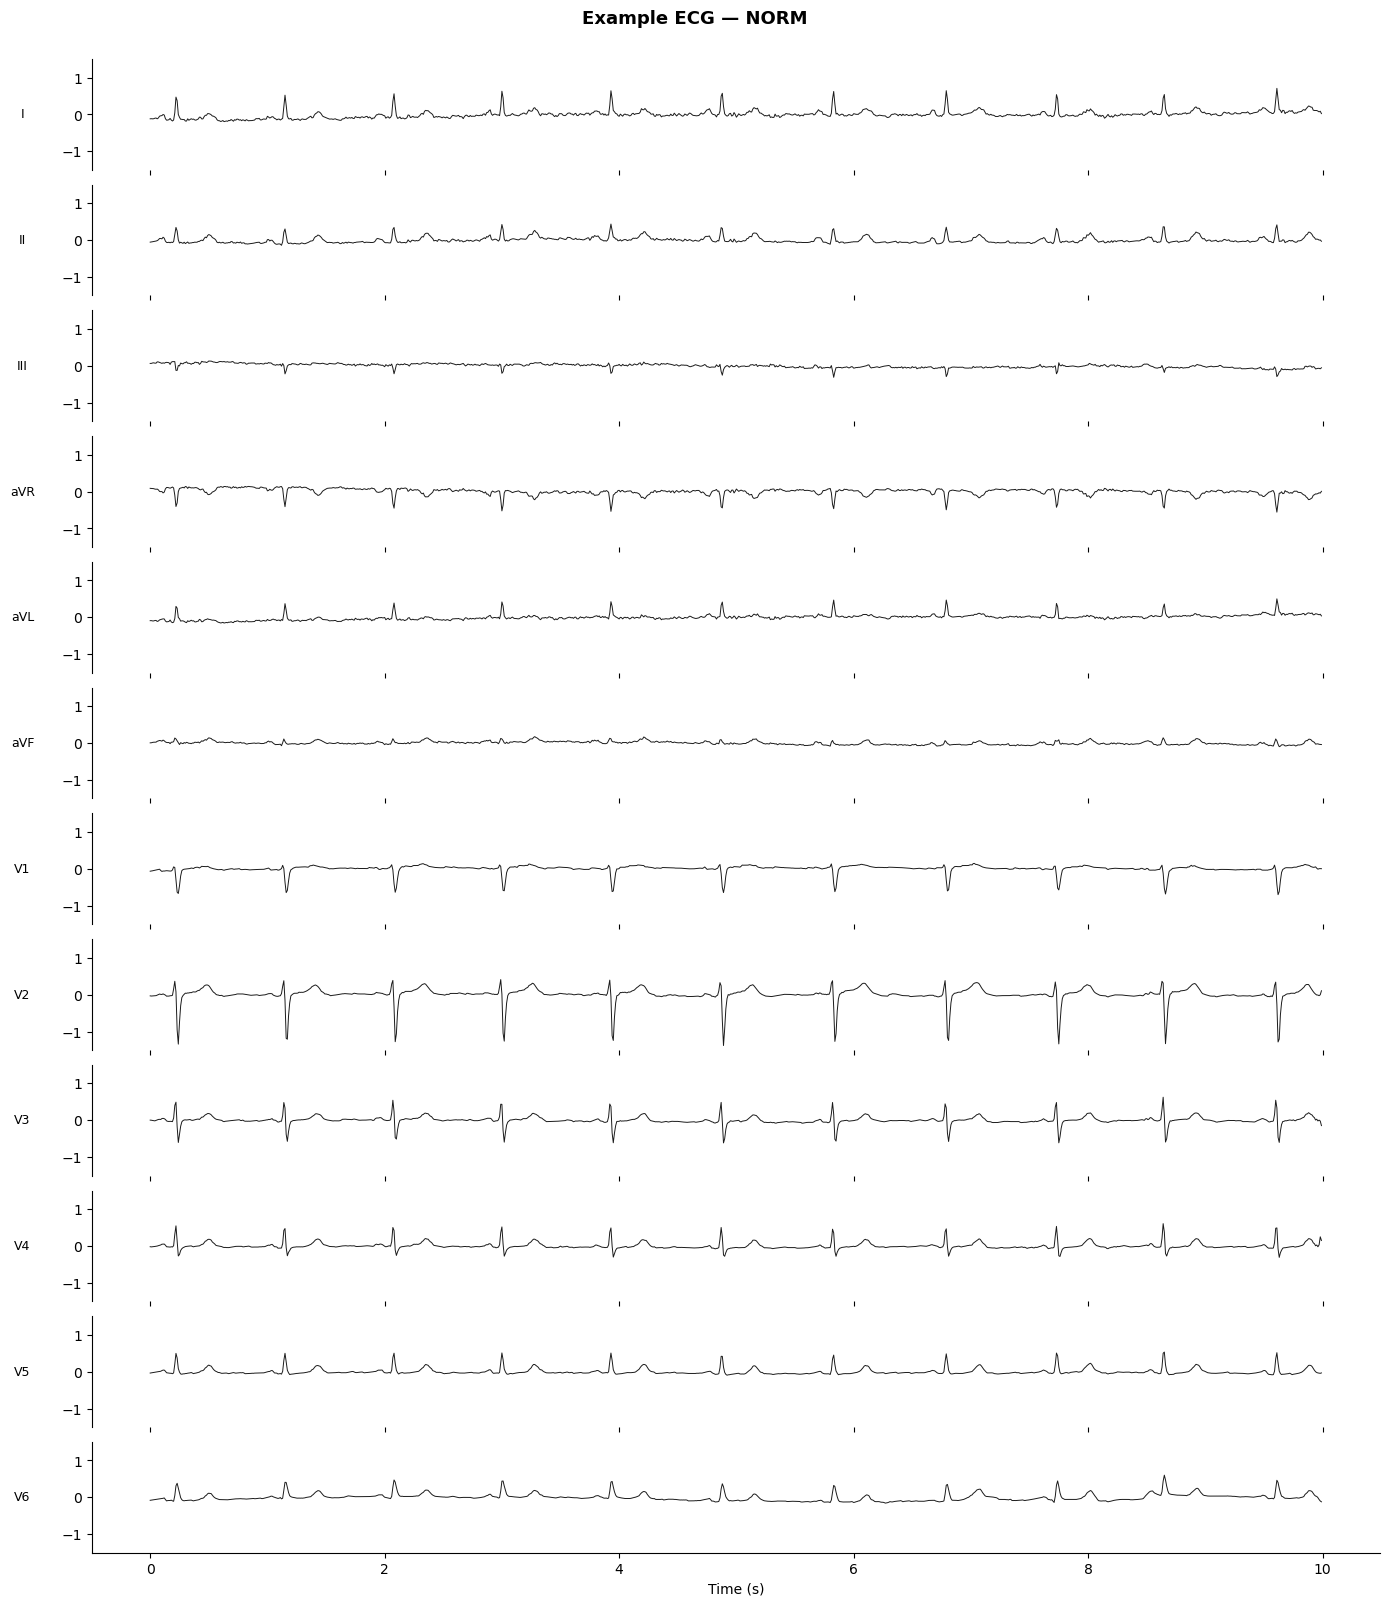

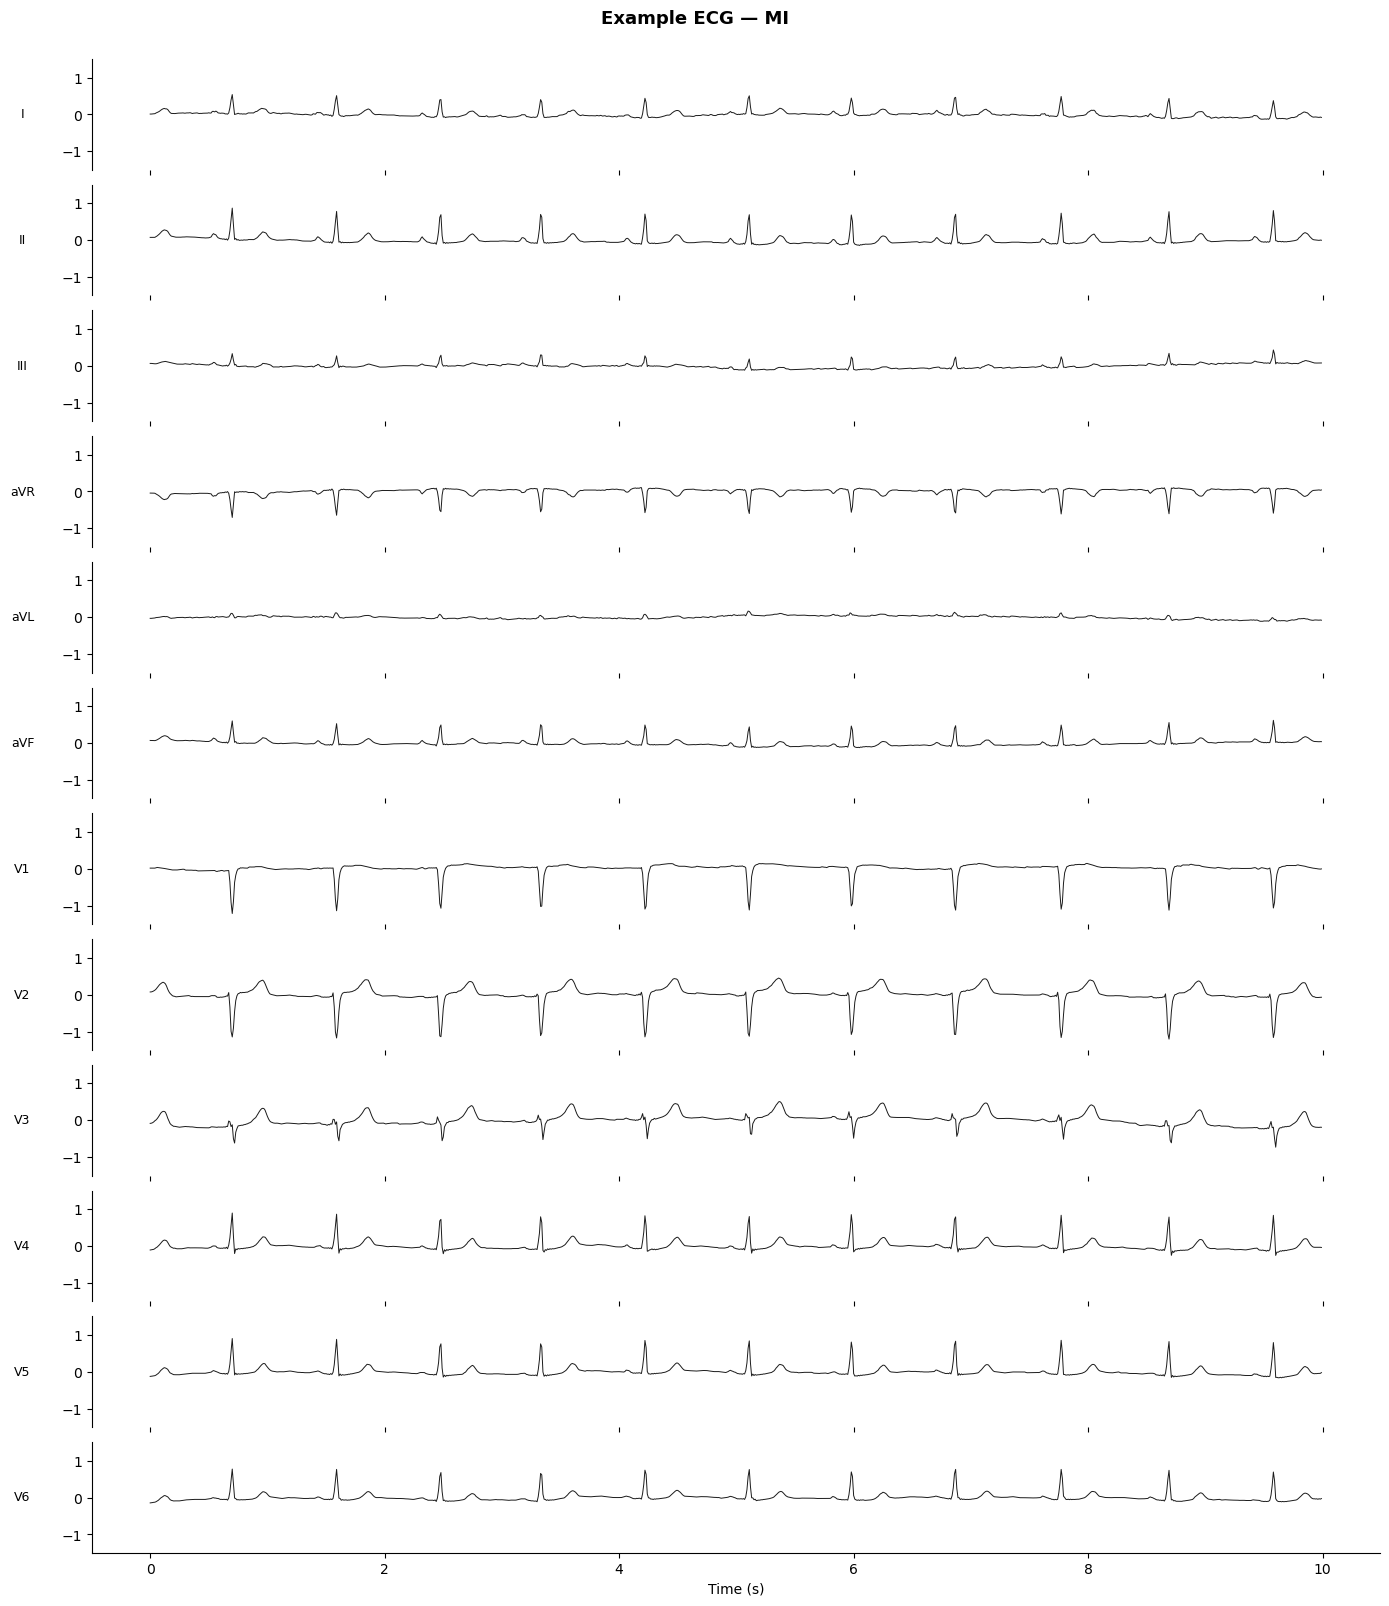

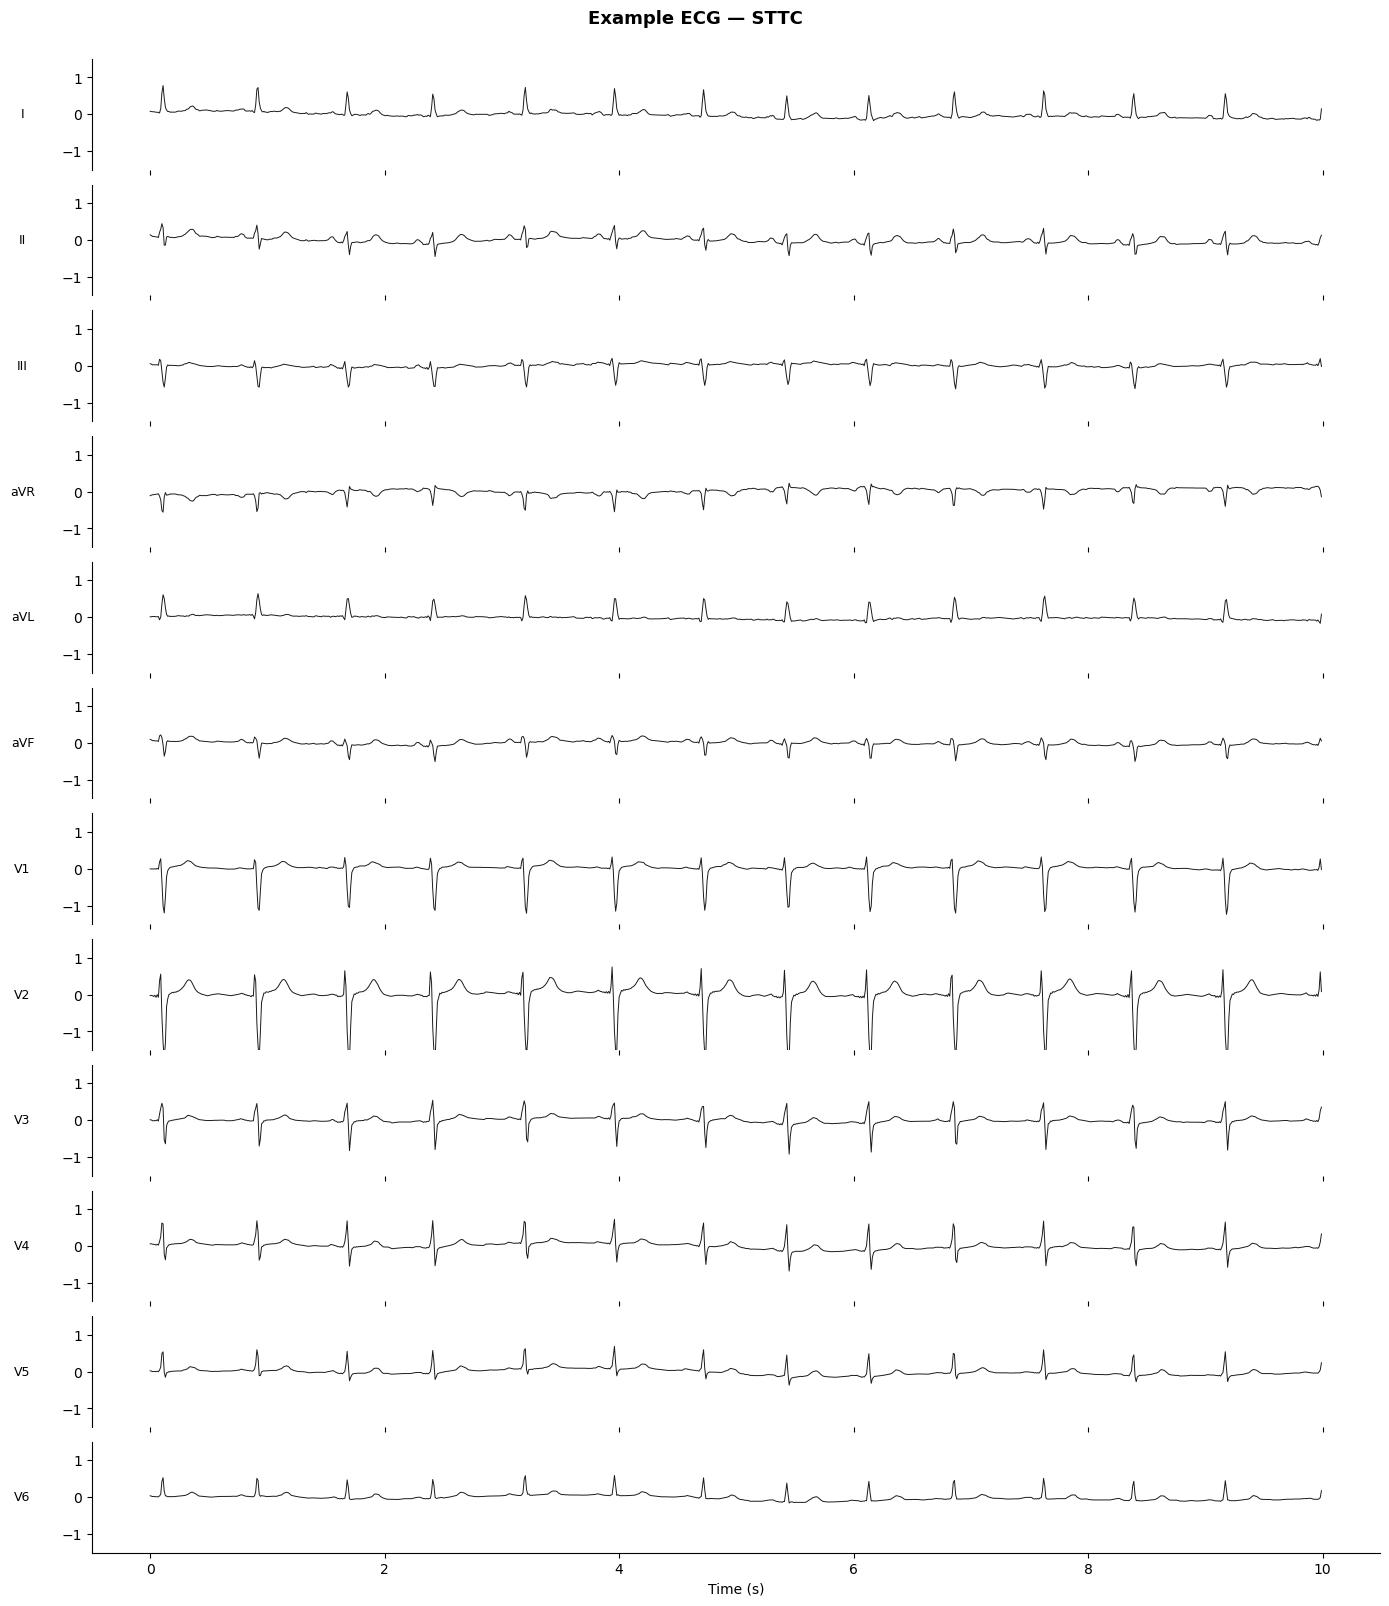

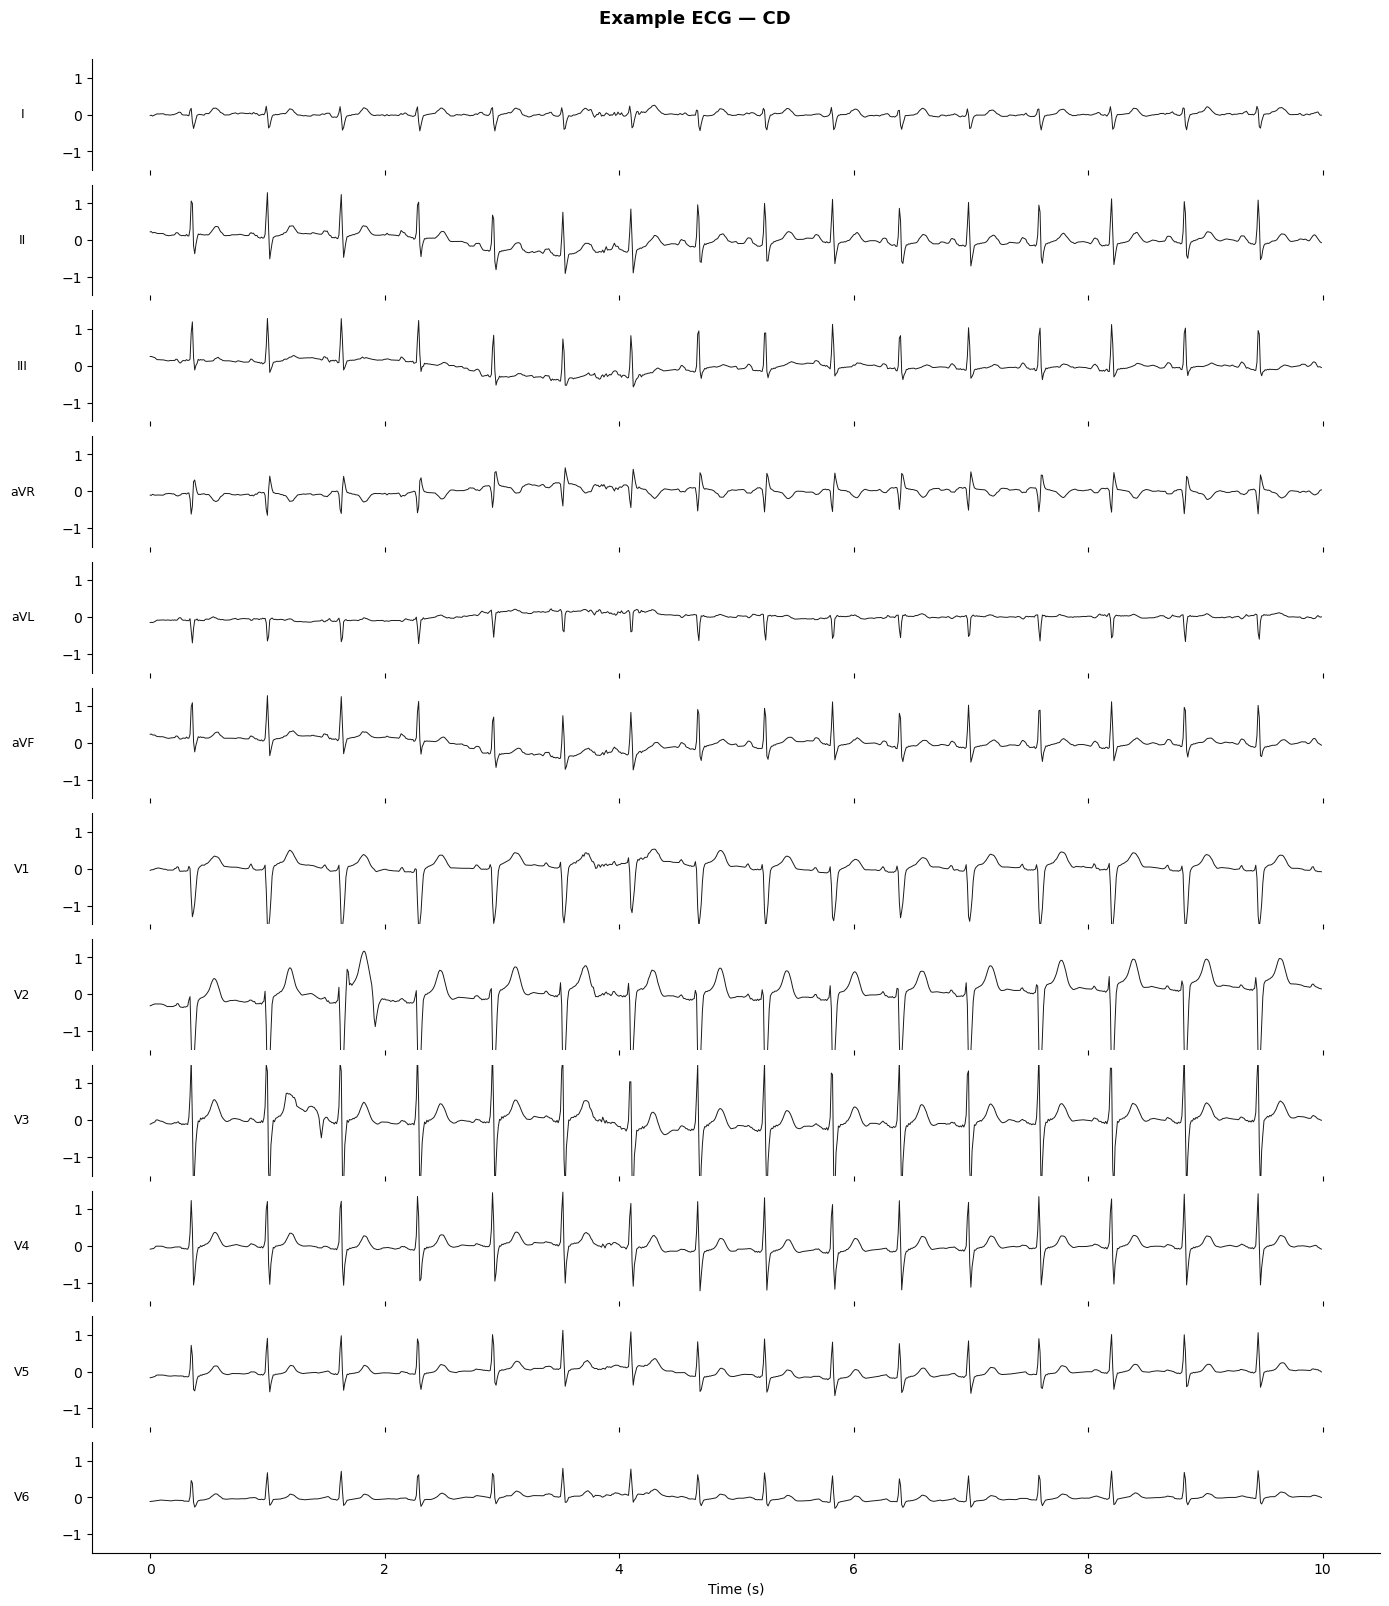

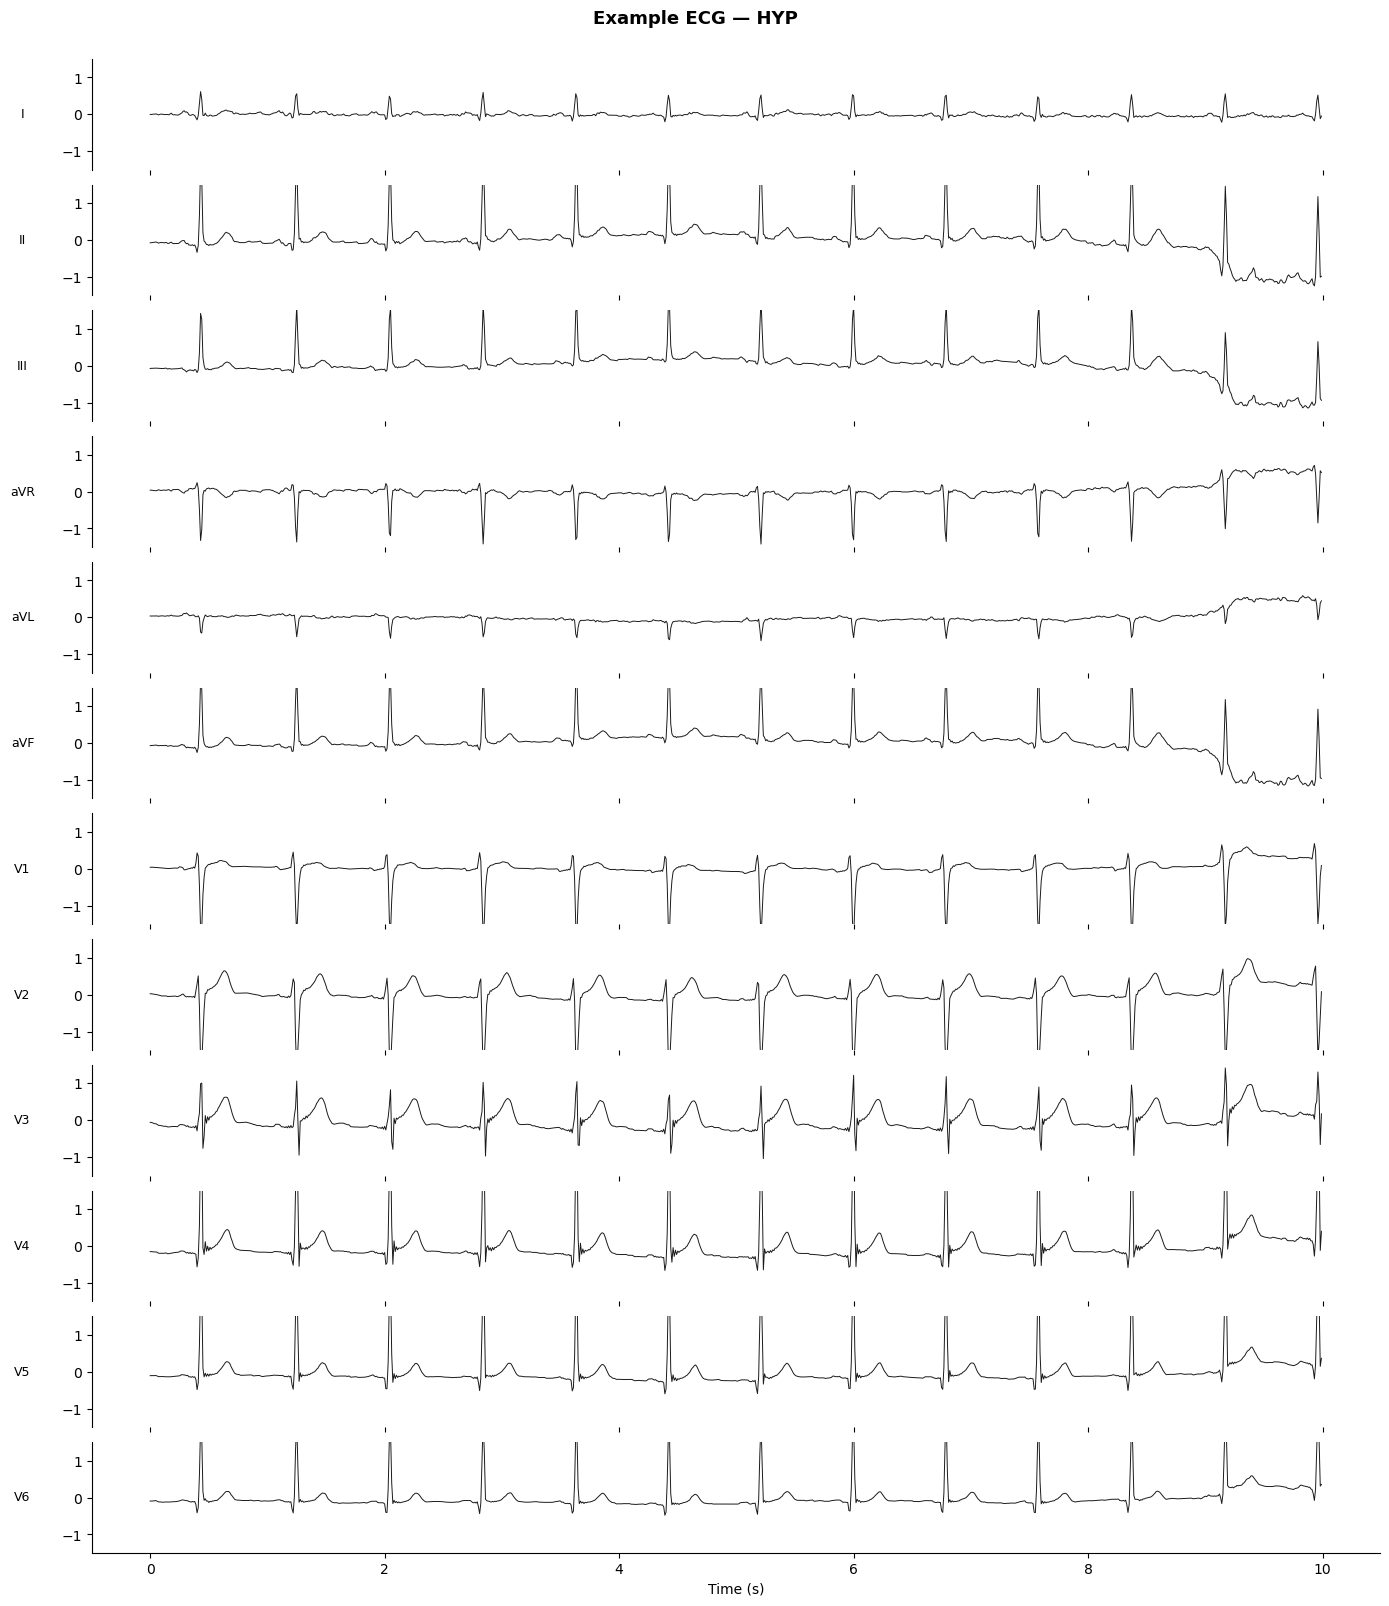

In [20]:
ecg_plots = {}
for cls, signal in samples.items():
    fig = plot_ecg(signal, title=f'Example ECG — {cls}', fs=100)
    ecg_plots[cls] = fig
    plt.show()

In [21]:
# Determine a comparison between clean and noisy records. Assert that a clean record visually looks fine against a flagged 'noisy' record
# Visually see what baseline_drift, static_noise, and burst_noise is before we decide how to handle those records

quality_cols = ['static_noise', 'burst_noise', 'baseline_drift', 
                'electrodes_problems', 'extra_beats', 'pacemaker']

# Check how many records are flagged for each
print(df[quality_cols].notna().sum())

static_noise           3206
burst_noise             581
baseline_drift         1579
electrodes_problems      28
extra_beats            1882
pacemaker                14
dtype: int64


In [22]:
quality_samples = load_quality_samples(df, DATA, fs=100)

# Sanity check 
for key, sig in quality_samples.items():
    print(f"{key}: shape={sig.shape}")

clean: shape=(1000, 12)
static_noise: shape=(1000, 12)
burst_noise: shape=(1000, 12)
baseline_drift: shape=(1000, 12)
electrodes_problems: shape=(1000, 12)
extra_beats: shape=(1000, 12)
pacemaker: shape=(1000, 12)


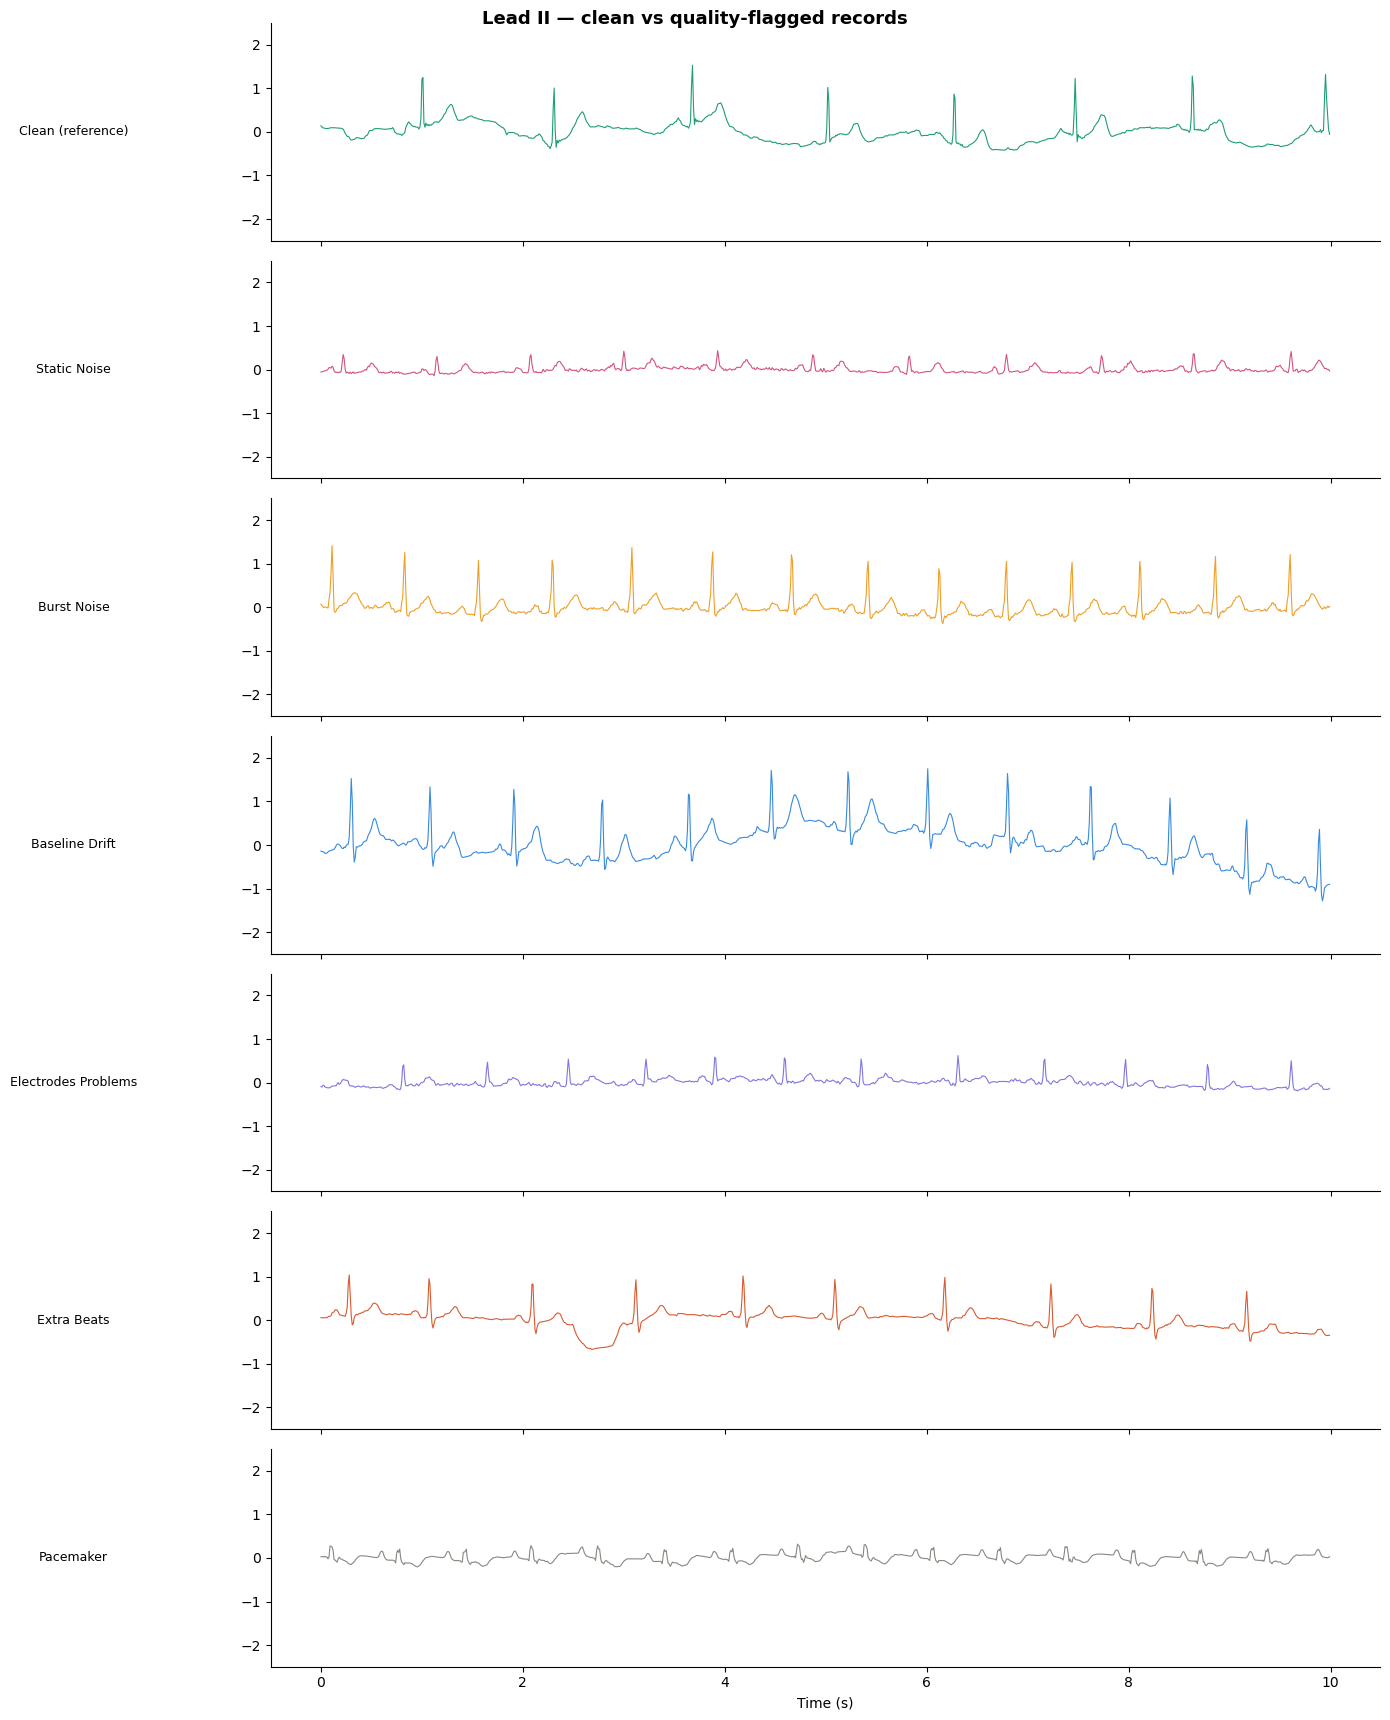

In [23]:
# Load examples of each quality type
fig = plot_quality_comparison(quality_samples, fs=100)
plt.show()

### Decision in data handling 
1. Baseline drift — this is removed by a bandpass filter (high-pass at 0.5 Hz cuts the slow drift). No special handling needed beyond standard preprocessing.
2. Static noise — partially by the low-pass filter (40 Hz cutoff). Residual noise may remain but the model should be robust to it given 3,206 flagged records are in the training set — it will see plenty of noisy examples.
3. Pacemaker and electrodes problems — only 14 and 28 records respectively. Too rare to meaningfully affect training but worth flagging in your validation report. Note their presence in the test set specifically:

In [24]:
# Check how many flagged records land in each split
quality_cols = ['static_noise', 'burst_noise', 'baseline_drift',
                'electrodes_problems', 'extra_beats', 'pacemaker']

quality_by_split = (
    df.groupby('split')[quality_cols]
    .apply(lambda g: g.notna().sum())
)

print(quality_by_split)

       static_noise  burst_noise  baseline_drift  electrodes_problems  \
split                                                                   
test            307           38             231                    2   
train          2578          496            1122                   22   
val             321           47             226                    4   

       extra_beats  pacemaker  
split                          
test           192          2  
train         1503         10  
val            187          2  


In [25]:
# Flag clean vs noisy in test set — save for validation notebook
test_df = df[df['split'] == 'test'].copy()
test_df['has_artifact'] = test_df[quality_cols].notna().any(axis=1)

print(test_df['has_artifact'].value_counts())
print(f"Clean test records:  {(~test_df['has_artifact']).sum()}")
print(f"Noisy test records:  {test_df['has_artifact'].sum()}")

has_artifact
False    1512
True      646
Name: count, dtype: int64
Clean test records:  1512
Noisy test records:  646


In [26]:
splits = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

stats_dict = {}
for key, df_split in splits.items():
    print(f"{'='*60}")
    print(f"Split: {key.upper()}  ({len(df_split):,} records)")
    print(f"{'='*60}")
    
    stats_dict[key] = compute_lead_stats(df_split, DATA, fs=100)
    print('\n')

Split: GLOBAL  (21,388 records)


Computing lead stats: 100%|██████████| 21388/21388 [02:04<00:00, 171.83it/s]




Split: TRAIN  (17,084 records)


Computing lead stats: 100%|██████████| 17084/17084 [00:42<00:00, 400.95it/s]




Split: VAL  (2,146 records)


Computing lead stats: 100%|██████████| 2146/2146 [00:05<00:00, 398.35it/s]




Split: TEST  (2,158 records)


Computing lead stats: 100%|██████████| 2158/2158 [00:05<00:00, 401.34it/s]

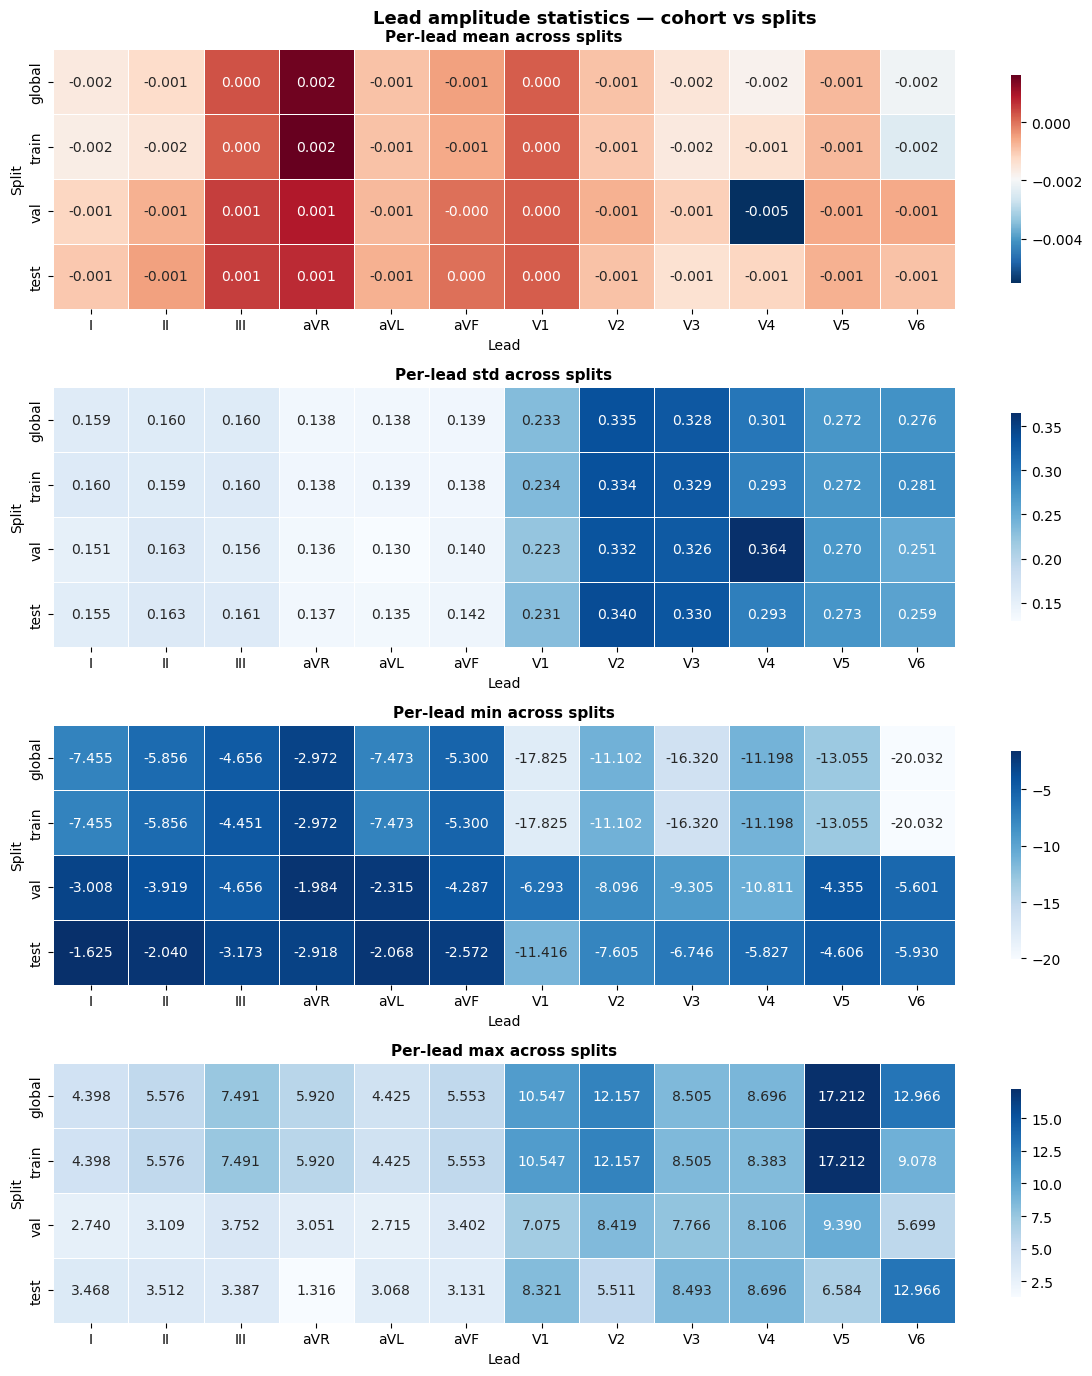

In [27]:
fig = plot_lead_stats(stats_dict)
plt.show()

## Lead Statistics Findings

1. All lead means ≈ 0 across all splits — no DC offset present.

2. Two amplitude groups identified:
   - Limb leads (I, II, III, aVR, aVL, aVF): std ≈ 0.13–0.16 mV
   - Precordial leads (V1–V6): std ≈ 0.22–0.33 mV
   This inter-lead difference is clinically meaningful and must be preserved.

3. Train/val/test statistics are consistent — stratification confirmed.

4. Extreme values present in training set (V1 min=-17.8, V6 min=-20.0).
   Likely outlier records — flagged for investigation.

Decision: Per-record z-score normalization confirmed.
Per-lead normalization explicitly rejected — would erase 
the clinically meaningful amplitude difference between 
limb and precordial leads.

## PSD

In [28]:
freqs, mean_psd = compute_mean_psd(df, DATA, fs=100)
print(f"Frequency bins: {freqs.shape}")  # expect (129,) at 100 Hz
print(f"Mean PSD shape: {mean_psd.shape}")  # expect (129, 12)

Computing PSD: 100%|██████████| 21388/21388 [01:29<00:00, 238.45it/s]

Frequency bins: (129,)
Mean PSD shape: (129, 12)


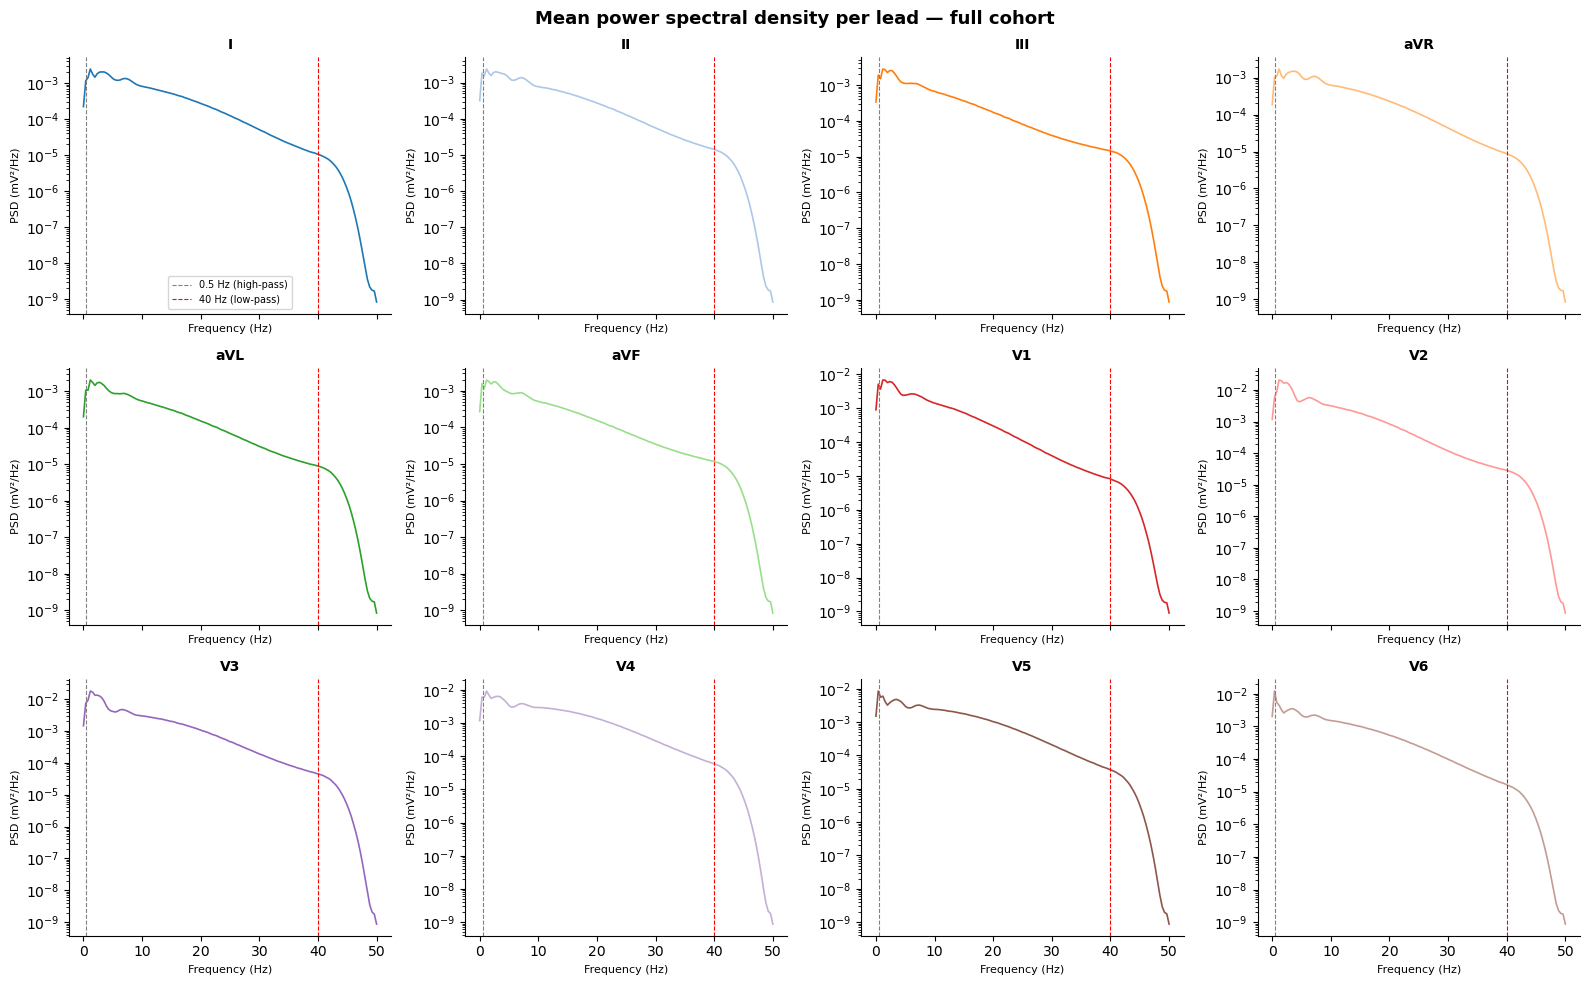

In [29]:
# Plot the PSD for each Lead
fig = plot_psd(freqs, mean_psd)
plt.show()

## Signal EDA — PSD Analysis Summary

Power spectral density (PSD) was computed across all 21,799 records using Welch's method 
(nperseg=256) at 100 Hz sampling frequency and averaged per lead across the full cohort.

### Findings

**Spectral decay:** All 12 leads exhibit a consistent pattern of decreasing power with 
increasing frequency, confirming that diagnostic ECG information is concentrated in the 
lower frequency bands. No lead showed flat or increasing spectral profiles.

**Baseline wander:** Elevated power near 0 Hz was observed across all leads, consistent 
with low-frequency baseline wander caused by patient movement and respiration. This 
confirms the need for a high-pass filter cutoff at 0.5 Hz as the first preprocessing step.

**Bandpass cutoff justified:** The majority of signal power falls below the 40 Hz 
threshold across all leads, confirming that a low-pass cutoff at 40 Hz preserves all 
clinically meaningful ECG components (P wave, QRS complex, T wave) while rejecting 
high-frequency noise. No meaningful power loss is introduced by this cutoff.

**Precordial vs limb lead amplitude:** Precordial leads (V1–V6) exhibited consistently 
higher overall power than limb leads (I, II, III, aVR, aVL, aVF), consistent with the 
amplitude statistics observed in the lead statistics analysis (precordial std ≈ 0.22–0.33 
vs limb std ≈ 0.13–0.16 mV). This inter-lead amplitude difference is clinically meaningful 
and is preserved by the chosen per-record z-score normalization strategy.

**Cross-lead consistency:** All 12 leads exhibited highly similar spectral shapes, 
confirming no lead is behaving anomalously and that the data loaded correctly across 
all channels.

### Decision

A zero-phase Butterworth bandpass filter (0.5–40 Hz, order 4) is confirmed as the 
appropriate preprocessing filter for this dataset. This is consistent with the standard 
diagnostic ECG bandwidth reported in the literature and adopted by the PTB-XL benchmark.

### Reference

Strodthoff, N., Wagner, P., Schaeffter, T., & Samek, W. (2021). Deep learning for ECG 
analysis: benchmarks and insights from PTB-XL. *IEEE Journal of Biomedical and Health 
Informatics*, 25(5), 1519–1528. https://doi.org/10.1109/JBHI.2020.3022989

### [Ten quick tips for electrocardiogram (ECG) signal processing](https://pmc.ncbi.nlm.nih.gov/articles/PMC11419615/) 

**Tip 1 — Understand the ECG before touching the computer**
Learn the PQRST complex, QRS complex, PR and ST intervals before doing any analysis. You should be able to read an ECG by eye first.

**Tip 2 — Define your medical context clearly**
Know exactly what condition you are trying to detect and which ECG abnormalities correspond to it. Collaborate with clinicians from the start and stay current with the literature.
* In this case we are attempting to classify conditions of ECG major abnormalities.

**Tip 3 — Ensure your data is suitable**
Data must match your scientific question. Check signal quality, recording length (at least 10 seconds for peak detection), and sampling rate. For clinical applications the recommended minimum is 512 Hz — worth noting since PTB-XL at 100 Hz is below this threshold, which is acceptable for classification but would be a limitation for HRV analysis.
* The closets frequency would be the 500 Hz variant of the dataset. We will switch to this folder for the final model.

**Tip 4 — Use open source tools**
Python and R are recommended. Relevant libraries for ECG specifically include `HeartPy`, `wfdb`, and `PhysioZoo`.
* wfdb is being used to read the samples and load them for analysis

**Tip 5 — Always preprocess — never analyze raw ECG**
Remove noise and baseline wander before any analysis. Use Signal Quality Indices (SQIs) to assess data suitability. Key SQIs include kurtosis, skewness, in-band to out-of-band spectral power ratio (5–40 Hz), and beat detection agreement between two algorithms.
* This statement serves as a valiation of the pre-processing that will occur with the ECG data.

**Tip 6 — Start simple, use complexity only when needed**
Try traditional algorithms before deep learning. Only use ResNet1D after confirming simpler baselines (logistic regression, random forest) are insufficient
* Our SAP will address this point by exploring simple and complex models

**Tip 7 — Use multiple metrics, never just accuracy**
For imbalanced multi-label classification always report sensitivity, specificity, precision, F1, and a metric that considers the full confusion matrix. The paper strongly advocates for Matthews Correlation Coefficient (MCC) over AUC 
* Worth considering adding MCC to the secondary endpoints alongside the existing SAP.

**Tip 8 — Present results clinicians can understand**
Figures should be self-explanatory. Provide results in formats clinicians can use independently (CSV tables with all relevant variables). Write results as if for a manuscript from the start.

**Tip 9 — Seek a validation cohort**
After validating on PTB-XL test set, look for an external ECG dataset to confirm generalizability. Candidate datasets mentioned include MedalCare-XL and others on PhysioNet. 
* This would significantly strengthen a regulatory-style submission.

**Tip 10 — Release data and code publicly**
Share your code on GitHub. Makes results reproducible and transparent.

## Pre-processing of ECG Signals

### Step 1 — Implement the preprocessing functions

In [30]:
# Load 10 records from training set
key      = 'filename_lr'
sample10 = df[df['split'] == 'train'].sample(n=10, random_state=42)

for _, row in sample10.iterrows():
    raw, _        = wfdb.rdsamp(str(DATA / row[key]))
    raw           = np.array(raw)
    preprocessed  = preprocess(raw, fs=100)

    assert preprocessed.shape == (1000, 12),  f"Wrong shape: {preprocessed.shape}"
    assert preprocessed.dtype == np.float32,  f"Wrong dtype: {preprocessed.dtype}"
    assert not np.isnan(preprocessed).any(),  f"NaN values detected"
    assert not np.isinf(preprocessed).any(),  f"Inf values detected"

print("All 10 records passed preprocessing sanity checks")

All 10 records passed preprocessing sanity checks


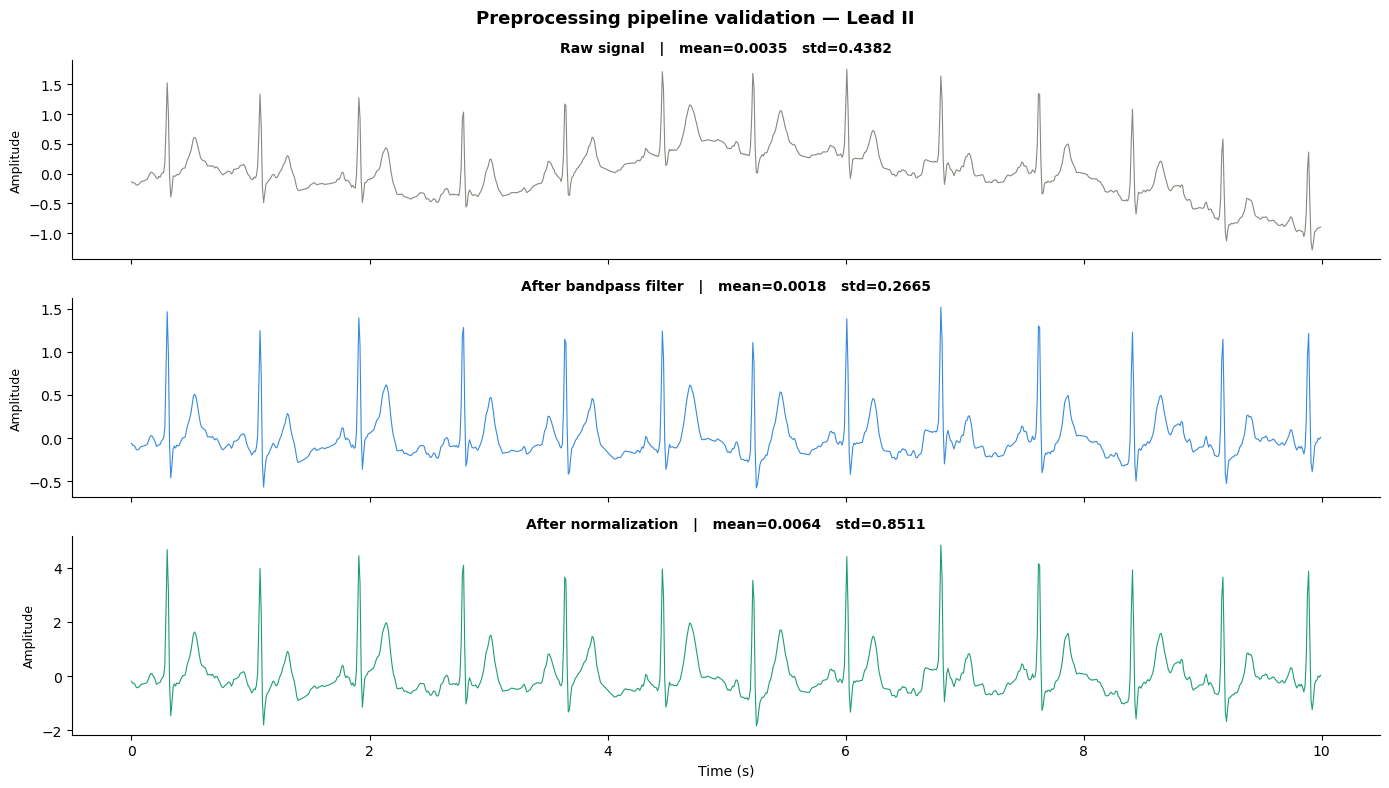

In [31]:
raw_signal        = quality_samples['baseline_drift']
filtered_signal   = bandpass_filter(raw_signal, fs=100)
processed_signal  = preprocess(raw_signal, fs=100)

fig = plot_preprocessing_comparison(raw_signal, filtered_signal, processed_signal, fs=100)
plt.show()

| Stage               | What we should see                                                                             |
|---------------------|------------------------------------------------------------------------------------------------|
| Raw                 | Visible baseline drift - signal drifting up and down slowly                                    |
| After Bandpass      | Baseline drift removed - signal centered around zero, QRS complexed remain intact              |
| After Normalization | Same shape as filtered, amplitude scaled to roughly plus or minus 1-3 std units, mean approx 0 |

## EDA Summary & Modeling Decisions

### Key Findings

| Finding | Value | Modeling implication |
|---|---|---|
| Total training records | ~17,440 | Batch size and epoch planning |
| Class imbalance (HYP) | 12.4% prevalence | `pos_weight` required |
| MI ↔ STTC co-occurrence | ~48–50% | Multi-label sigmoid output confirmed |
| NORM median age | ~54 vs ~67 pathological | Age is a confounder — include in subgroup analysis |
| MI male skew | ~59% male | Sex subgroup analysis required for MI specifically |
| Validated-by-human (test) | Higher rate than train | Test set label quality is high |
| Static noise in test | ~14% of test records | Report clean vs noisy performance separately |
| Dominant signal bandwidth | 0.5–40 Hz | Confirmed by PSD analysis |
| Normalization strategy | Per-record z-score | Per-lead rejected — erases limb/precordial difference |

In [32]:
# ── Decisions to carry forward into modeling.ipynb ────────────────────────────

# Splits — use author-recommended folds
# folds 1-8 = train | fold 9 = val | fold 10 = test

# Class order
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Sampling rate
FS = 100  # upgrade to 500 Hz for final model run

# Input shape
# (N, 12, 1000) — (batch, leads, timesteps) at 100 Hz

# Preprocessing pipeline
# 1. Bandpass filter: 0.5–40 Hz, Butterworth order 4, zero-phase (filtfilt)
# 2. Normalization: per-record z-score across all leads jointly

# pos_weight for BCEWithLogitsLoss — compute from training split
Y_train    = mlb.fit_transform(df[df['split'] == 'train']['superclass'])
pos        = Y_train.sum(axis=0)
neg        = len(Y_train) - pos
pos_weight = neg / pos
print("pos_weight per class:")
print(dict(zip(CLASS_ORDER, pos_weight.round(2))))

# Save to artifacts folder
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)

np.save(ARTIFACTS / 'pos_weight.npy', pos_weight)
print(f"\nSaved to: {ARTIFACTS / 'pos_weight.npy'}")

# Test set subgroup flags — carry into validation notebook
quality_cols           = ['static_noise', 'burst_noise', 'baseline_drift',
                          'electrodes_problems', 'extra_beats', 'pacemaker']
test_df                = df[df['split'] == 'test'].copy()
test_df['has_artifact'] = test_df[quality_cols].notna().any(axis=1)
print(f"\nClean test records:  {(~test_df['has_artifact']).sum()}")
print(f"Noisy test records:  {test_df['has_artifact'].sum()}")

test_df[['has_artifact']].to_csv(ARTIFACTS / 'test_artifact_flags.csv')
print(f"Saved to: {ARTIFACTS / 'test_artifact_flags.csv'}")

pos_weight per class:
{'NORM': np.float64(1.25), 'MI': np.float64(2.9), 'STTC': np.float64(3.08), 'CD': np.float64(3.37), 'HYP': np.float64(7.06)}

Saved to: c:\Users\delga\OneDrive\Documents\personal_projects\DeepAF Automated Atrial Fibrillation Detection\ecg-ai-statistical-evaluation\artifacts\pos_weight.npy

Clean test records:  1512
Noisy test records:  646
Saved to: c:\Users\delga\OneDrive\Documents\personal_projects\DeepAF Automated Atrial Fibrillation Detection\ecg-ai-statistical-evaluation\artifacts\test_artifact_flags.csv
